Test y validación del modelo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sys
fh = 24
sys.path.append('../src')


df_raw = pd.read_csv('../data/raw/PJME_hourly.csv', parse_dates=['Datetime'], index_col='Datetime')
df_raw = df_raw.sort_index()
df_raw = df_raw.groupby(df_raw.index).mean() 
assert df_raw.index.is_unique
df_raw = df_raw.asfreq('h')

# Interpolación para los huecos de spring forward (son ~16 horas en 16 años)
print(f"NaNs por DST: {df_raw['PJME_MW'].isna().sum()}")
df_raw['PJME_MW'] = df_raw['PJME_MW'].interpolate(method='time')

# Verificación final
assert df_raw['PJME_MW'].isna().sum() == 0
assert df_raw.index.freq is not None
print("Dataset limpio y listo")

NaNs por DST: 30
Dataset limpio y listo


In [2]:
# Serie original sin shift
endog = np.log(df_raw['PJME_MW'])

# Proporciones
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO  = 0.15 implícito

n         = len(endog)
train_end = int(n * TRAIN_RATIO)
val_end   = train_end + int(n * VAL_RATIO)

endog_train = endog.iloc[:train_end]
endog_val   = endog.iloc[train_end:val_end]
endog_test  = endog.iloc[val_end:]

# Verificar continuidad
assert (endog_val.index[0] - endog_train.index[-1])  == pd.Timedelta('1h'), "Gap train→val"
assert (endog_test.index[0] - endog_val.index[-1])   == pd.Timedelta('1h'), "Gap val→test"

# Resumen
print(f"Total observaciones: {n:,}")
print(f"\n{'Set':<10} {'Start':<25} {'End':<25} {'Samples':>10} {'%':>6}")
print("-" * 80)
for name, s in [('Train', endog_train), ('Val', endog_val), ('Test', endog_test)]:
    print(f"{name:<10} {str(s.index[0]):<25} {str(s.index[-1]):<25} {len(s):>10,} {len(s)/n*100:>5.1f}%")

Total observaciones: 145,392

Set        Start                     End                          Samples      %
--------------------------------------------------------------------------------
Train      2002-01-01 01:00:00       2013-08-11 14:00:00          101,774  70.0%
Val        2013-08-11 15:00:00       2016-02-06 06:00:00           21,808  15.0%
Test       2016-02-06 07:00:00       2018-08-03 00:00:00           21,810  15.0%


In [3]:
# =============================================================================
# MÉTRICAS
# =============================================================================

def evaluate(y_true, y_pred, split_name=''):
    mean_true = np.mean(y_true)
    std_true = np.std(y_true)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"\nMétricas [{split_name}]")
    print(f"  mean_true  : {mean_true:,.2f} MW")
    print(f"  std_true  : {std_true:,.2f} MW")
    print(f"  MAE  : {mae:,.2f} MW")
    print(f"  RMSE : {rmse:,.2f} MW")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R2 : {r2:.4f}")
    return {'mean_true': mean_true, 'std_true': std_true, 'mae': mae, 'rmse': rmse, 'mape': mape, 'R2': r2}



# =============================================================================
# VISUALIZACIÓN — muestra una semana para que sea legible
# =============================================================================

def plot_forecast(y_true, y_pred, title, n_days=7):
    n = n_days * 24
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    y_pred_a = y_pred.reindex(y_true.index)
    y_pred = y_pred_a
    # Plot 1: primeros n_days
    axes[0].plot(y_true.index[:n], y_true.values[:n], label='Real',       color='steelblue')
    axes[0].plot(y_pred.index[:n], y_pred.values[:n], label='Predicción', color='tomato', linestyle='--')
    axes[0].set_title(f'{title} — primeros {n_days} días')
    axes[0].legend()
    axes[0].set_ylabel('MW')

    # Plot 2: error absoluto
    error = np.abs(y_true.values[:n] - y_pred.values[:n])
    axes[1].fill_between(y_true.index[:n], error, alpha=0.5, color='tomato')
    axes[1].set_title('Error absoluto (MW)')
    axes[1].set_ylabel('MW')

    plt.tight_layout()
    plt.show()

In [ ]:
# model = SARIMAX(endog_train[:], order=(1,1,1), seasonal_order=(1,0,1,24), trend='n')
# result = model.fit(disp=False, cov_type='none')


In [4]:
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / 'sarimax_24.pkl'


In [ ]:
# # Guardar
# result.save(models_dir / 'sarimax_24.pkl', remove_data=True)
# print(f"Modelo guardado en {model_path}")


Modelo guardado en ..\models\sarimax_24.pkl


In [8]:
# Cargar
from statsmodels.tsa.statespace.sarimax import SARIMAXResultsWrapper
result = SARIMAXResultsWrapper.load(models_dir / 'sarimax_24.pkl')


Métricas [Validación]
  mean_true  : 31,505.5 MW
  std_true  : 6,191.4 MW
  MAE  : 217.6 MW
  RMSE : 303.8 MW
  MAPE : 0.71%
  R2 : 0.9976


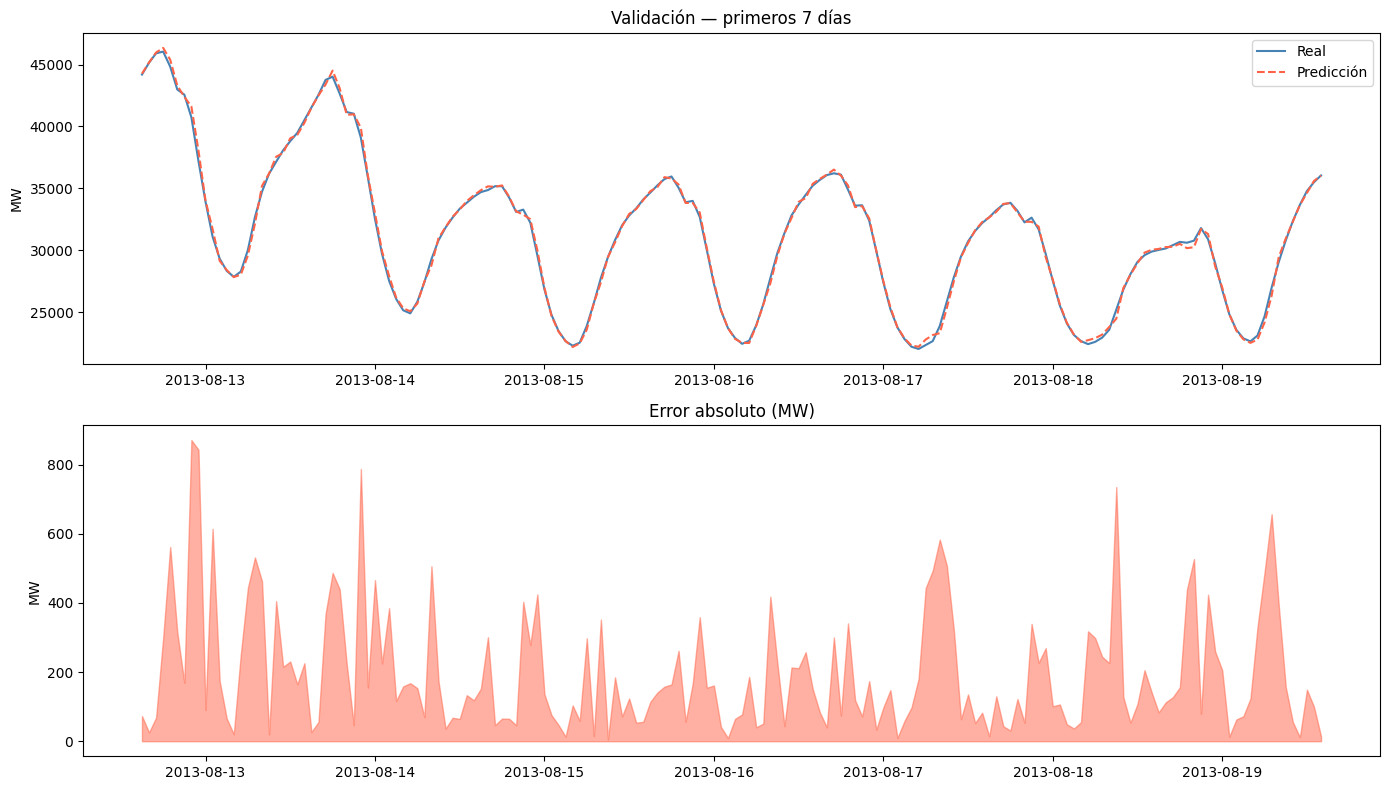

In [14]:
# # get_forecast genera predicciones out-of-sample paso a paso
# forecast_val = result.get_forecast(steps=len(endog_val))
# pred_val_log = forecast_val.predicted_mean

result_val    = result.apply(endog_val)   
pred_val_log  = result_val.fittedvalues
pred_val      = np.exp(pred_val_log)
real_val      = np.exp(endog_val)

warmup = 24
metrics_val = evaluate(real_val.iloc[warmup:], pred_val.iloc[warmup:], 'Validación')
plot_forecast(real_val.iloc[warmup:], pred_val.iloc[warmup:], 'Validación')

Train termina en:    2010-09-15 23:00:00
Datos futuros desde: 2010-09-16 00:00:00
Gap:                 0 days 01:00:00

--- Paso 1 | 2010-09-16 (Thursday) ---

Métricas [Paso 1 — Thursday]
  mean_true  : 31,157.00 MW
  std_true  : 5,041.54 MW
  MAE  : 1,638.78 MW
  RMSE : 1,895.33 MW
  MAPE : 4.88%
  R2 : 0.8587


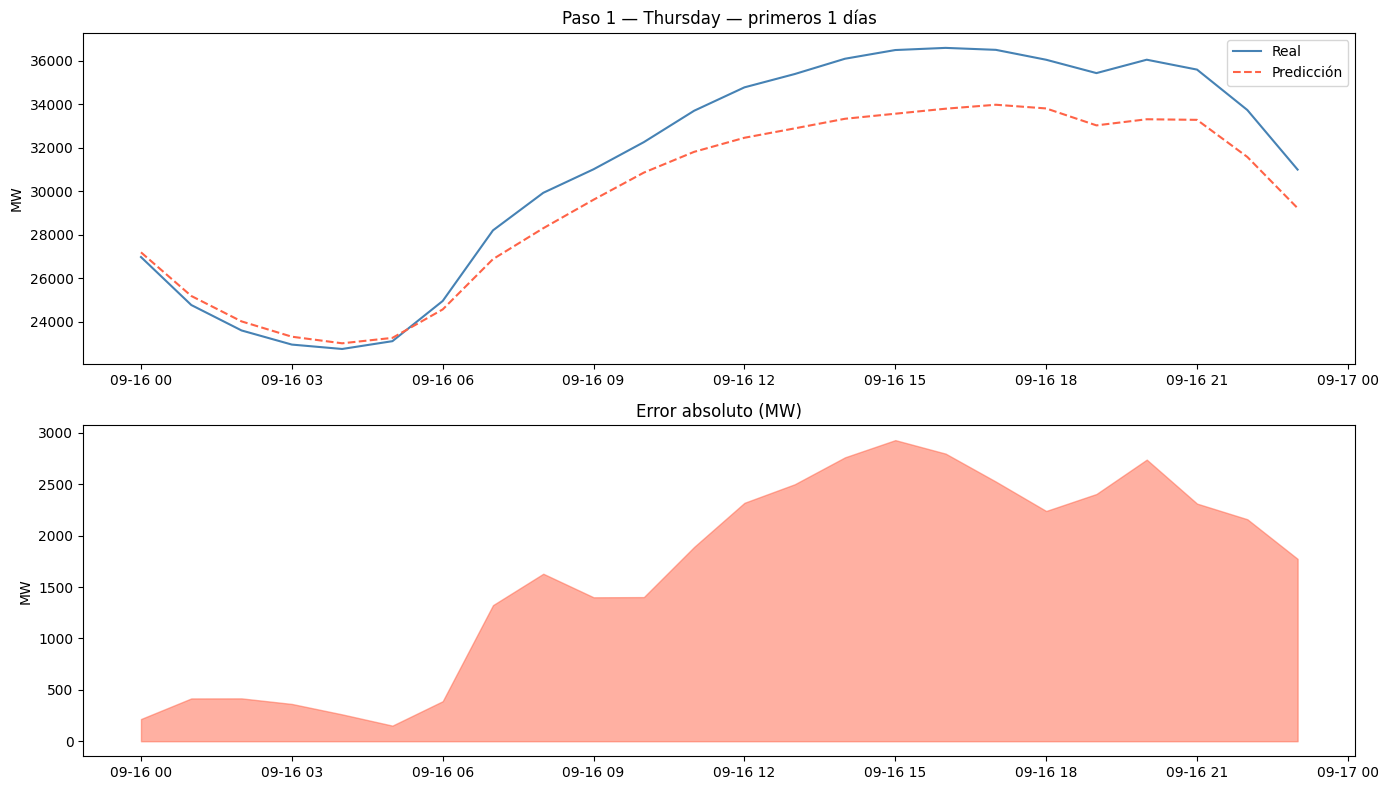


--- Paso 2 | 2010-09-17 (Friday) ---

Métricas [Paso 2 — Friday]
  mean_true  : 31,408.50 MW
  std_true  : 4,246.04 MW
  MAE  : 1,144.95 MW
  RMSE : 1,352.79 MW
  MAPE : 3.63%
  R2 : 0.8985


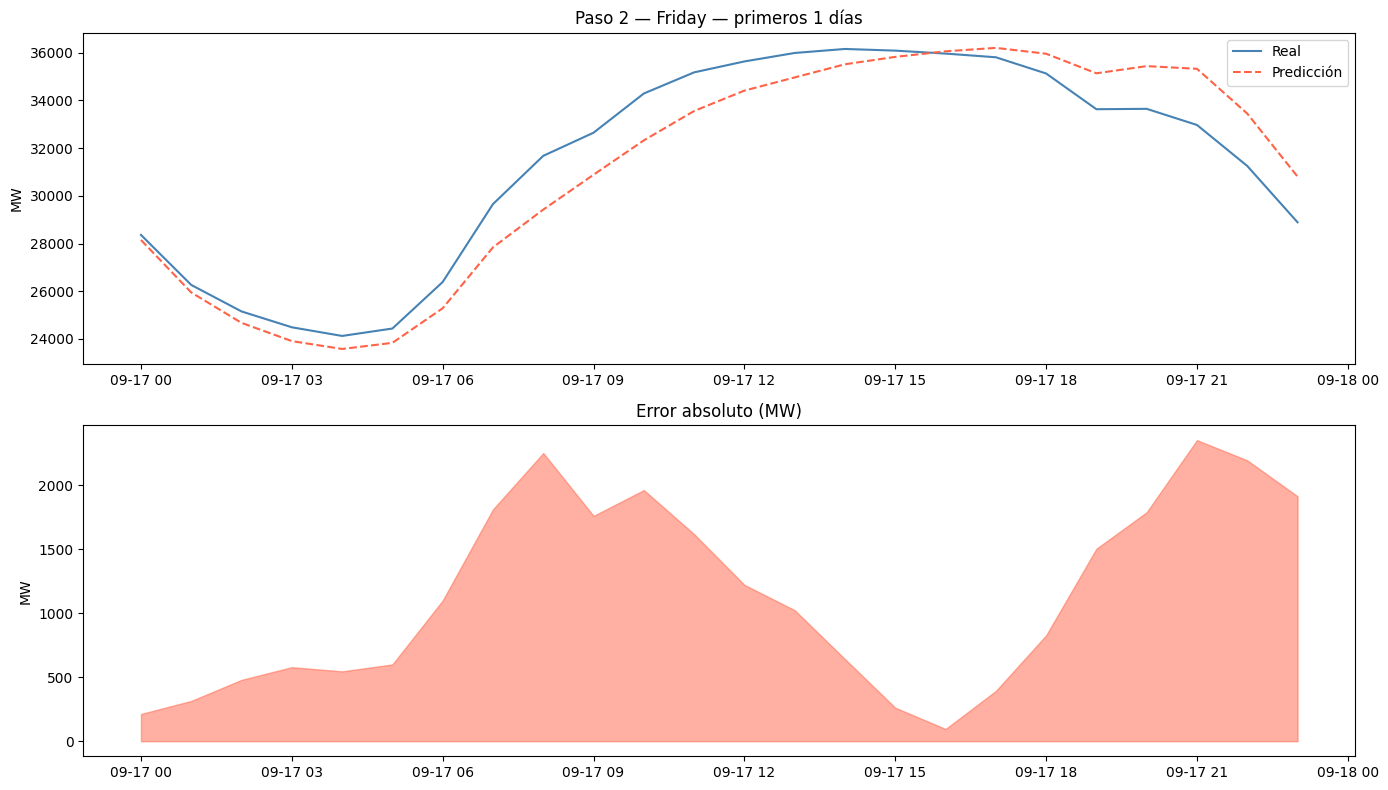


--- Paso 3 | 2010-09-18 (Saturday) ---

Métricas [Paso 3 — Saturday]
  mean_true  : 26,866.33 MW
  std_true  : 3,197.88 MW
  MAE  : 2,265.41 MW
  RMSE : 2,583.12 MW
  MAPE : 8.39%
  R2 : 0.3475


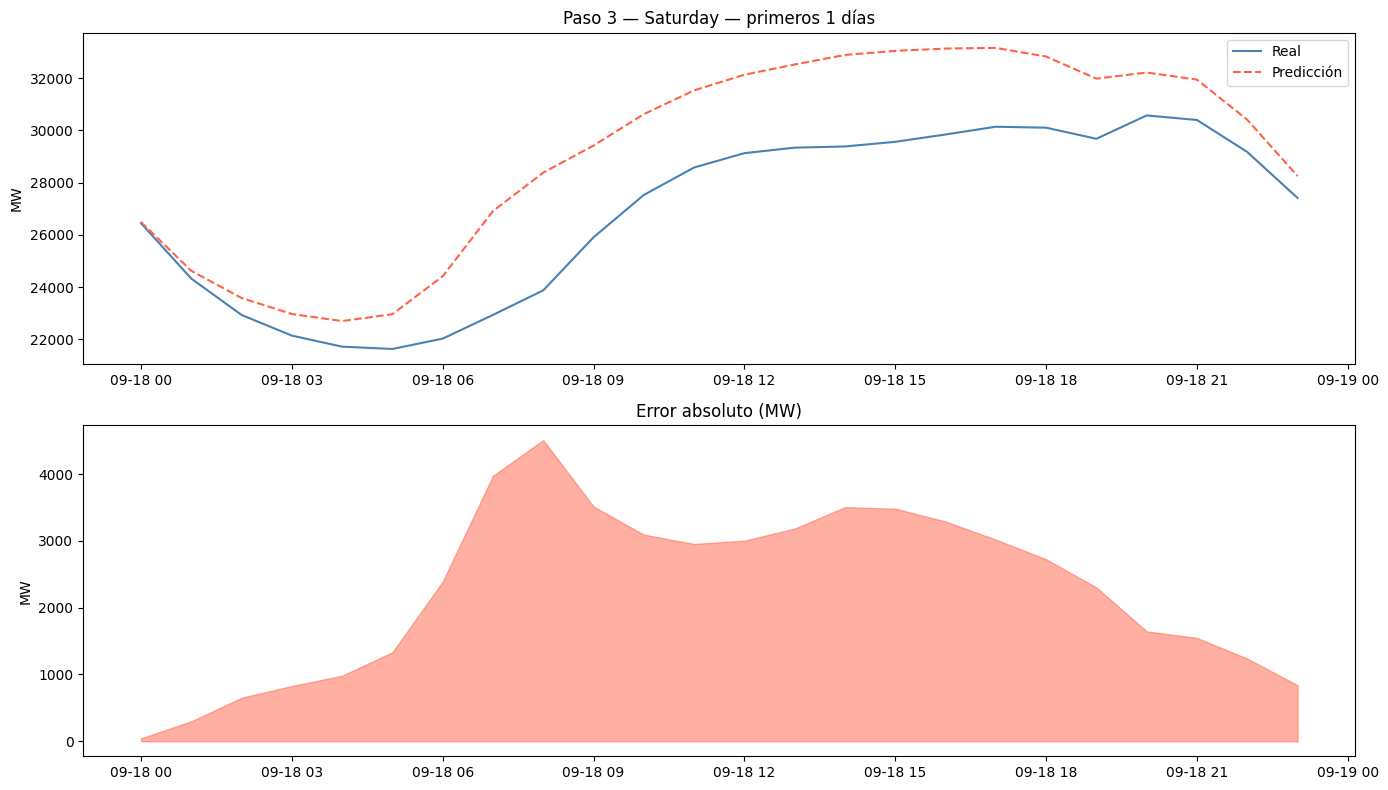


--- Paso 4 | 2010-09-19 (Sunday) ---

Métricas [Paso 4 — Sunday]
  mean_true  : 27,727.71 MW
  std_true  : 4,773.41 MW
  MAE  : 1,816.57 MW
  RMSE : 2,230.90 MW
  MAPE : 6.47%
  R2 : 0.7816


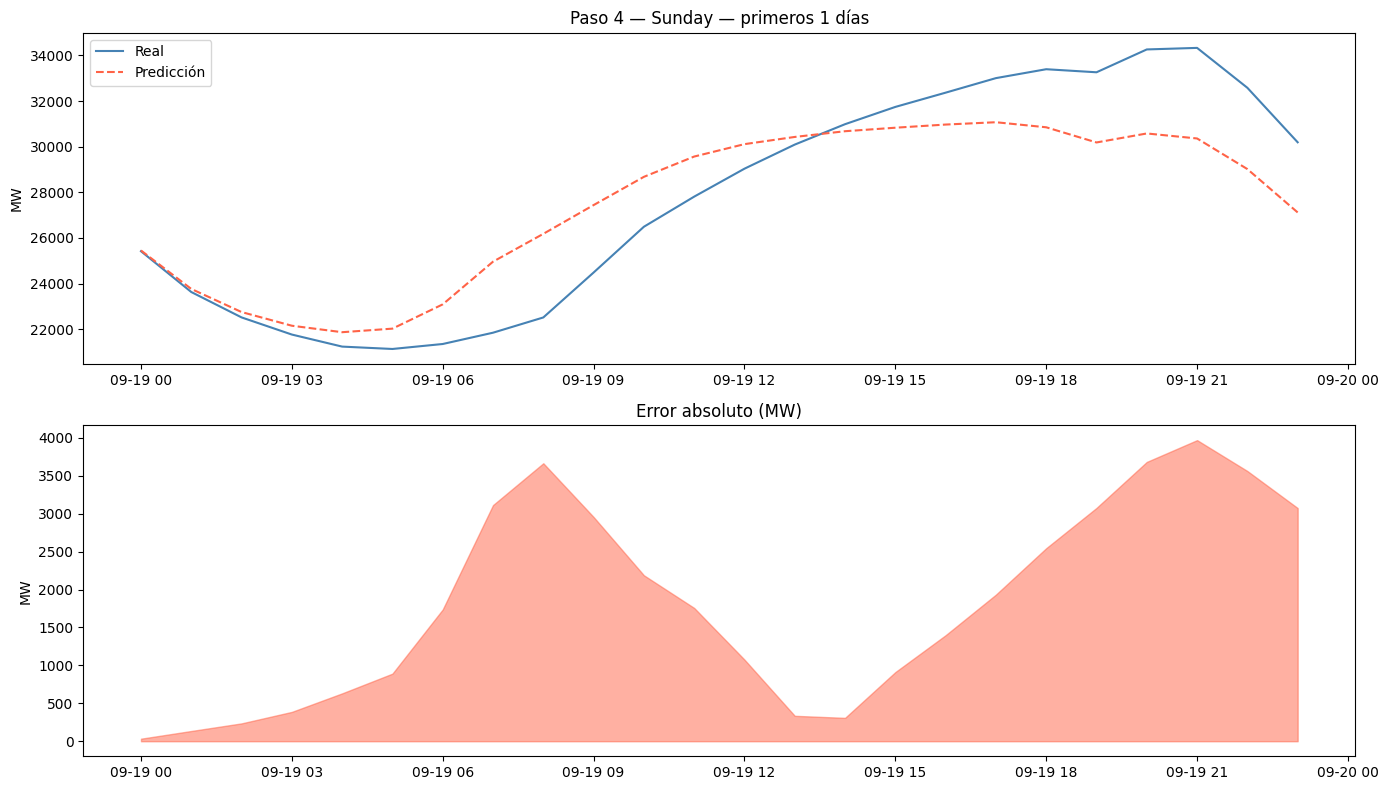


--- Paso 5 | 2010-09-20 (Monday) ---

Métricas [Paso 5 — Monday]
  mean_true  : 30,636.50 MW
  std_true  : 4,119.86 MW
  MAE  : 1,047.69 MW
  RMSE : 1,325.81 MW
  MAPE : 3.33%
  R2 : 0.8964


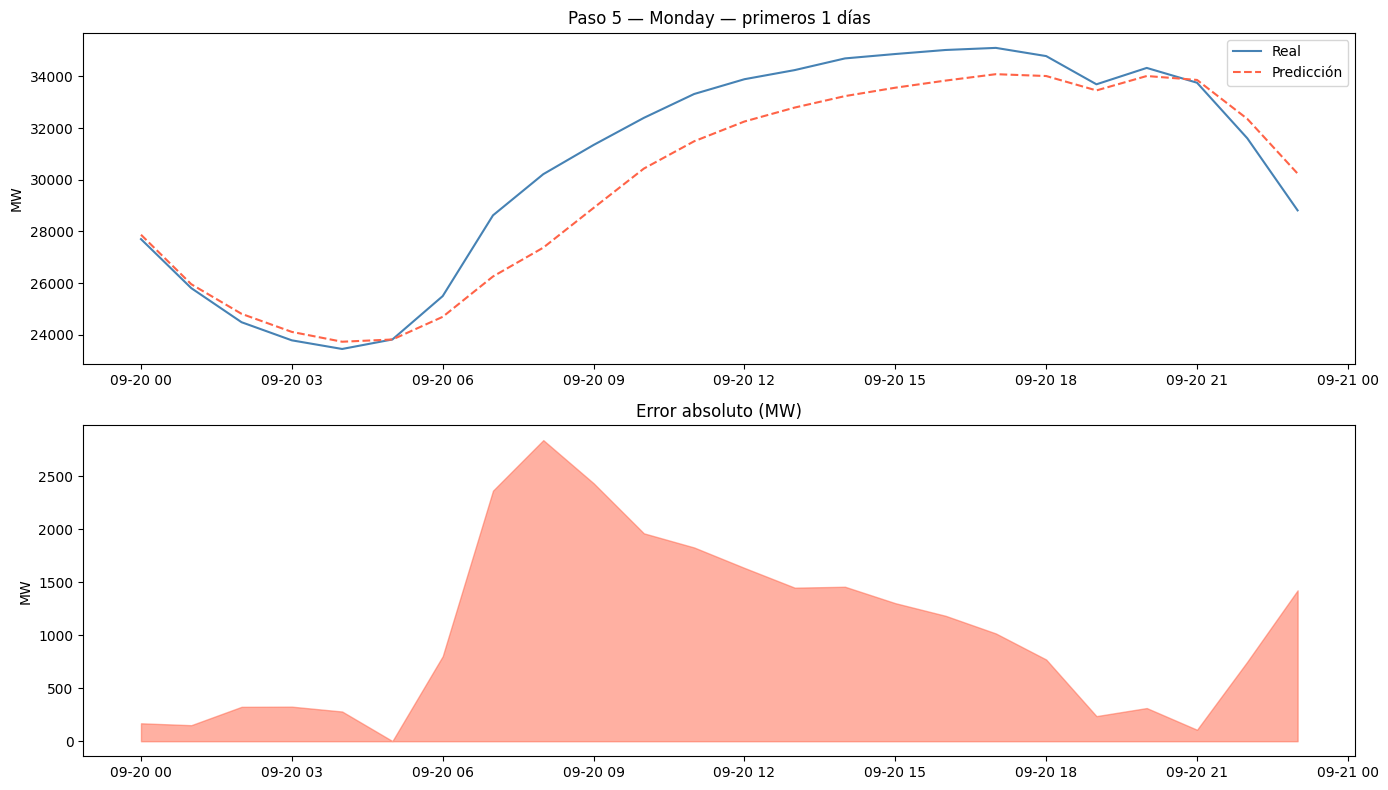


--- Paso 6 | 2010-09-21 (Tuesday) ---

Métricas [Paso 6 — Tuesday]
  mean_true  : 29,689.04 MW
  std_true  : 4,444.70 MW
  MAE  : 1,837.98 MW
  RMSE : 2,112.45 MW
  MAPE : 5.80%
  R2 : 0.7741


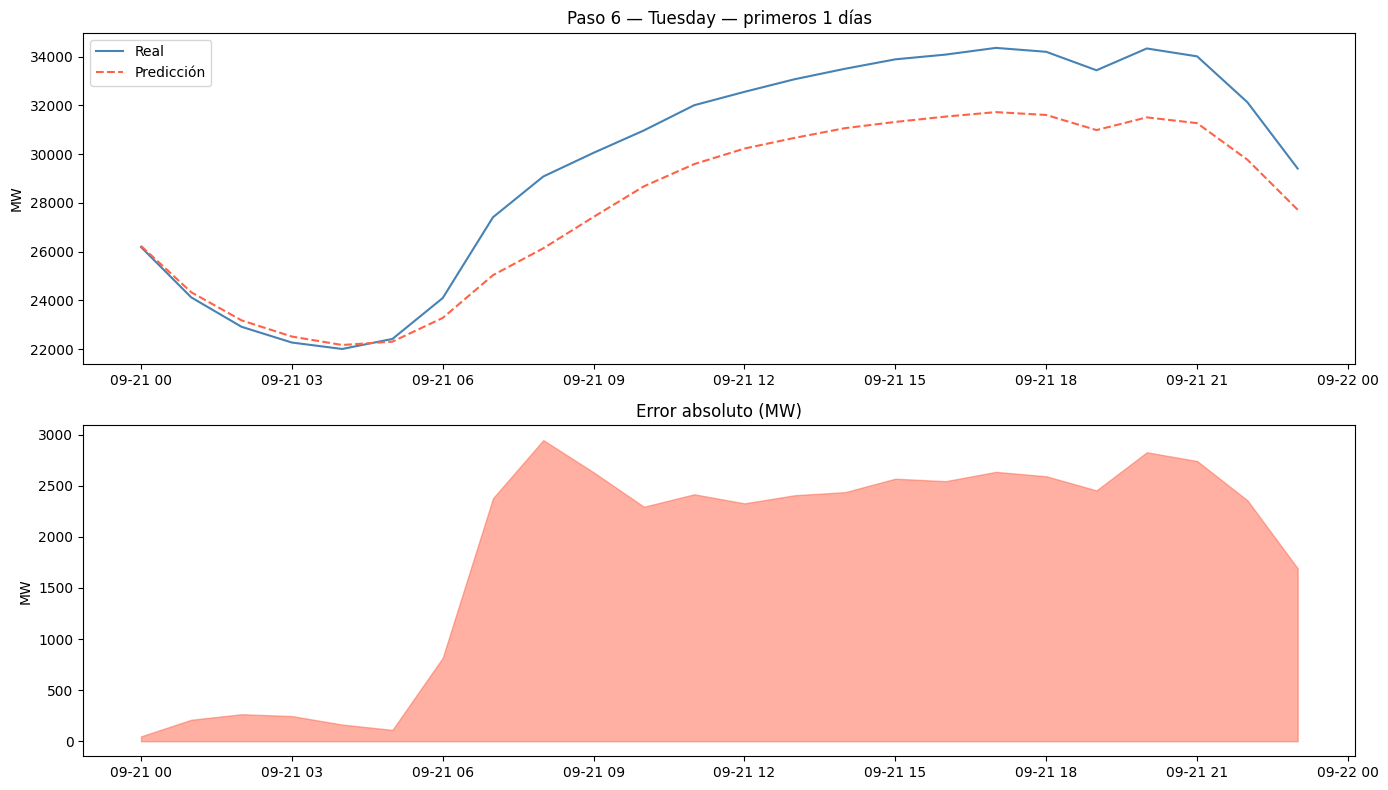



Métricas [Rolling Forecast 24h ahead — Global]
  mean_true  : 29,580.85 MW
  std_true  : 4,671.54 MW
  MAE  : 1,625.23 MW
  RMSE : 1,970.28 MW
  MAPE : 5.42%
  R2 : 0.8221


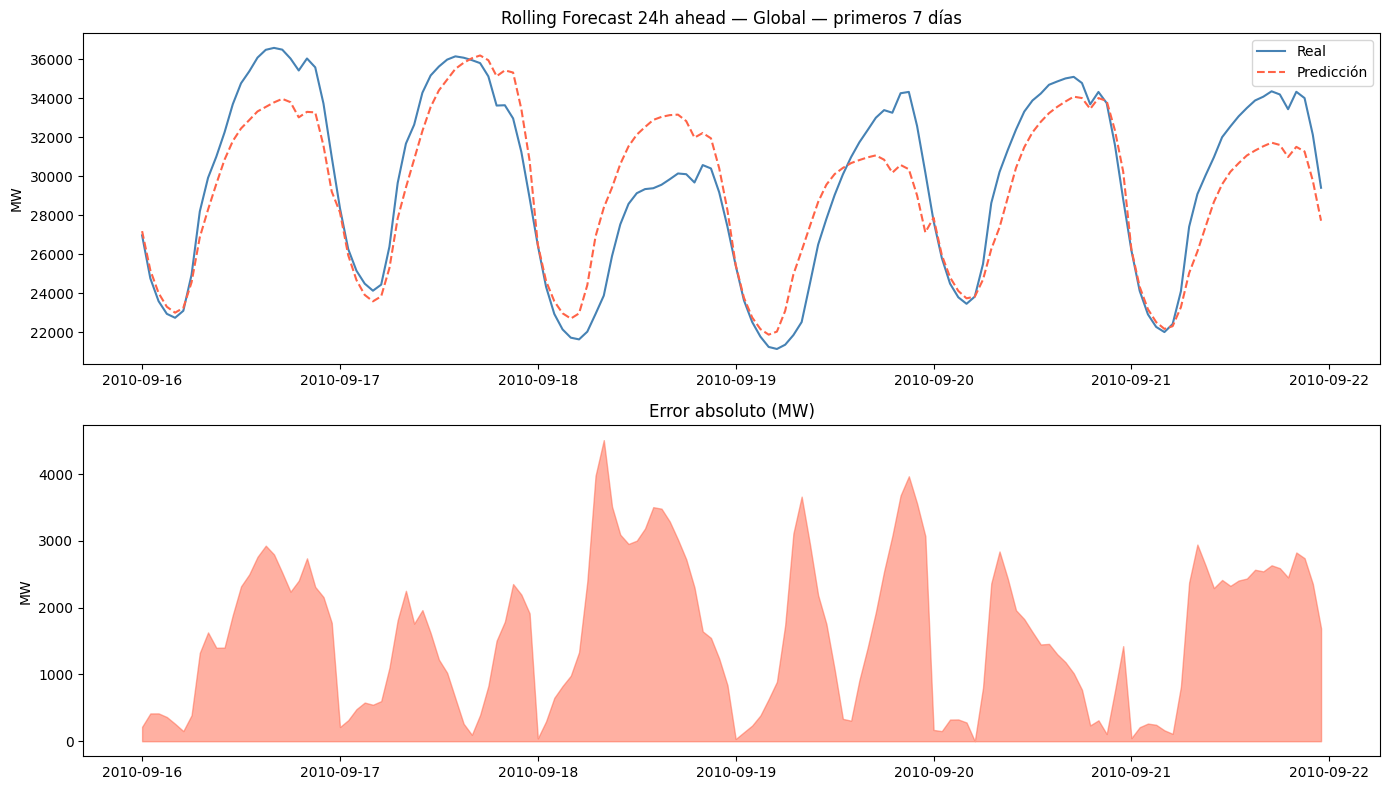

In [4]:
# Rolling forecast — predice 24h ahead en cada paso
# Simula el uso real del modelo en producción

k = int(len(endog_train) * 0.75)
train_inicial = endog_train[:k]

# Alinear train a hora 23:00
ultimo_23 = train_inicial[train_inicial.index.hour == 23].index[-1]
train_inicial_alineado = train_inicial[:ultimo_23]

# Datos futuros: continuar exactamente desde el siguiente punto del train alineado
inicio_futuros  = ultimo_23 + pd.Timedelta('1h')   # 2007-10-22 00:00
datos_alineados = endog_train[inicio_futuros:][:168]  # 7 días desde ahí

print(f"Train termina en:    {train_inicial_alineado.index[-1]}")
print(f"Datos futuros desde: {datos_alineados.index[0]}")
print(f"Gap:                 {datos_alineados.index[0] - train_inicial_alineado.index[-1]}")
# → debe dar 0 days 01:00:00

preds = []

for i in range(0, len(datos_alineados) - 24, 24):
    warm_up = pd.concat([train_inicial_alineado, datos_alineados.iloc[:i]])

    model = SARIMAX(warm_up, order=(1,1,1),
                    seasonal_order=(1,0,1,24), trend='n')
    res   = model.fit(disp=False, cov_type='none')
    fc    = res.get_forecast(steps=24)

    real_step_mw  = np.exp(datos_alineados.iloc[i:i+24])
    pred_step_log = fc.predicted_mean

    # Verificar alineación
    expected_start = warm_up.index[-1] + pd.Timedelta('1h')
    assert fc.predicted_mean.index[0] == expected_start, \
        f"Desalineación: pred={fc.predicted_mean.index[0]} esperado={expected_start}"

    pred_step_log.index = real_step_mw.index
    pred_step_mw  = np.exp(pred_step_log)

    dia = real_step_mw.index[0].day_name()
    print(f"\n--- Paso {i//24+1} | {real_step_mw.index[0].date()} ({dia}) ---")
    evaluate(real_step_mw, pred_step_mw, f'Paso {i//24+1} — {dia}')
    plot_forecast(real_step_mw, pred_step_mw, f'Paso {i//24+1} — {dia}', n_days=1)

    preds.append(pred_step_log)

# Resumen global
print("\n" + "="*50)
pred_log = pd.concat(preds)
pred_mw  = np.exp(pred_log)
real_mw  = np.exp(datos_alineados.iloc[:len(pred_mw)])
evaluate(real_mw, pred_mw, 'Rolling Forecast 24h ahead — Global')
plot_forecast(real_mw, pred_mw, 'Rolling Forecast 24h ahead — Global', n_days=7)

=== CHECK DE ALINEACIÓN ===
Longitud pred_mw : 144
Longitud real_mw : 144
✅ Longitudes iguales
✅ Todos los timestamps coinciden perfectamente

Rango real : 2010-09-16 00:00:00  →  2010-09-21 23:00:00
Rango pred : 2010-09-16 00:00:00  →  2010-09-21 23:00:00


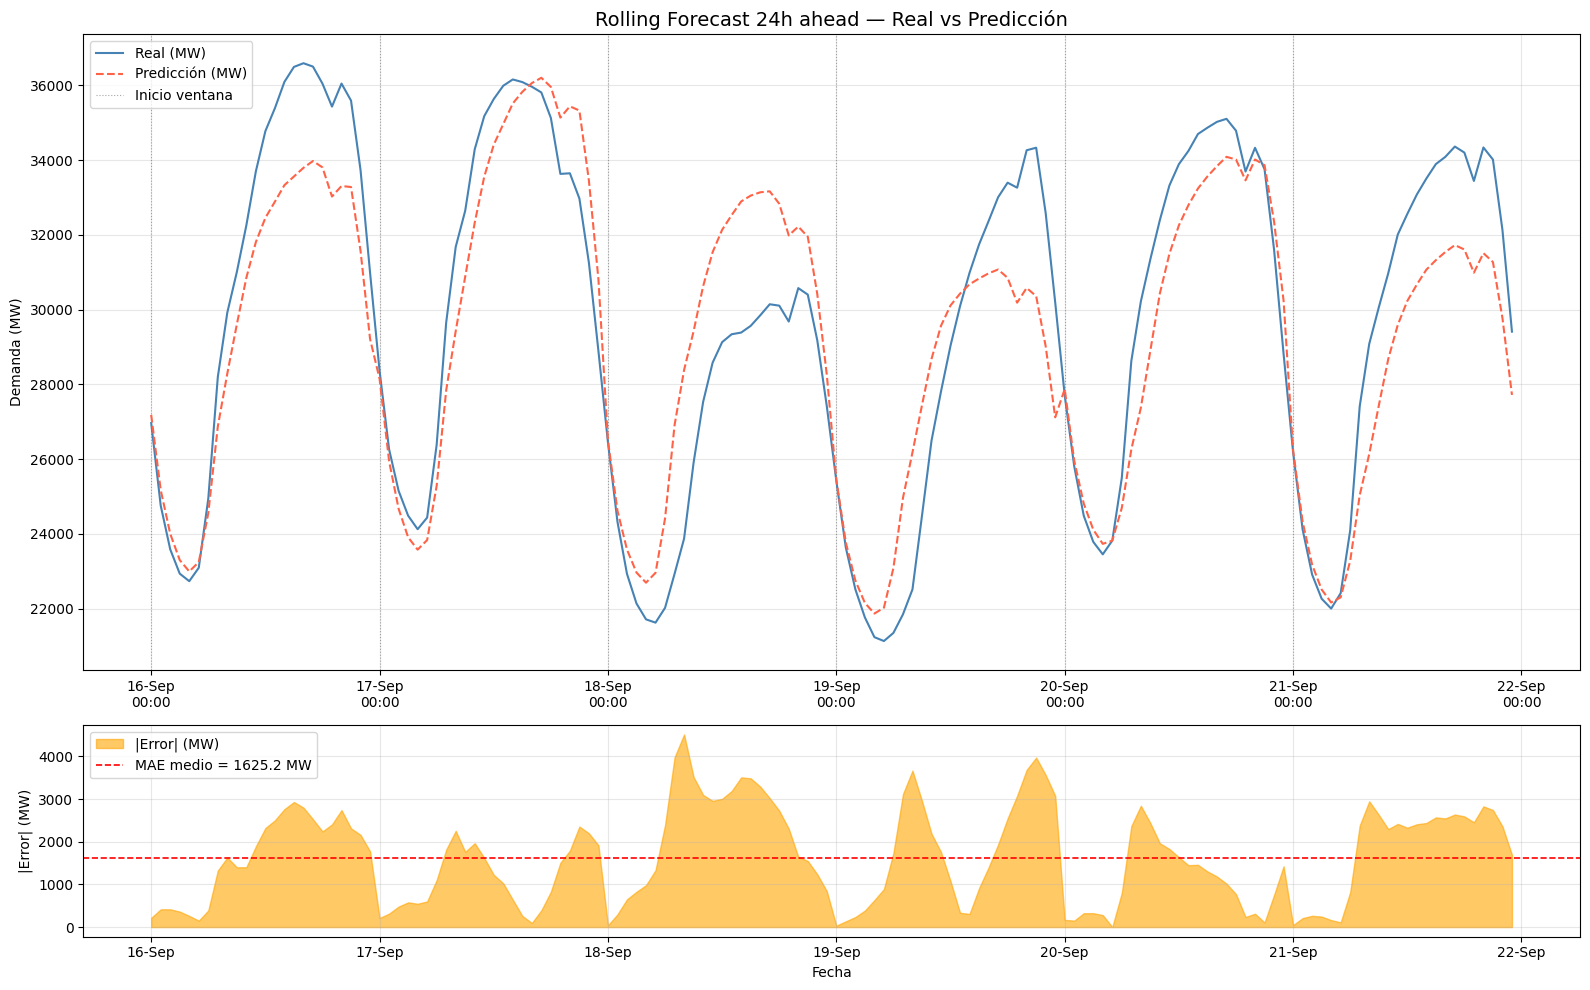

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Verificación de alineación ──────────────────────────────────────────────
print("=== CHECK DE ALINEACIÓN ===")
print(f"Longitud pred_mw : {len(pred_mw)}")
print(f"Longitud real_mw : {len(real_mw)}")

if len(pred_mw) != len(real_mw):
    print("⚠️  ADVERTENCIA: longitudes distintas")
else:
    print("✅ Longitudes iguales")

# Verificar que los índices coincidan exactamente
mismatches = pred_mw.index != real_mw.index
if mismatches.any():
    print(f"❌ HAY {mismatches.sum()} DESALINEACIONES:")
    print(pred_mw.index[mismatches].tolist())
else:
    print("✅ Todos los timestamps coinciden perfectamente")

print(f"\nRango real : {real_mw.index[0]}  →  {real_mw.index[-1]}")
print(f"Rango pred : {pred_mw.index[0]}  →  {pred_mw.index[-1]}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10),
                         gridspec_kw={'height_ratios': [3, 1]})

# — Panel superior: real vs predicho —
ax = axes[0]
ax.plot(real_mw.index, real_mw.values, color='steelblue',
        linewidth=1.5, label='Real (MW)', zorder=3)
ax.plot(pred_mw.index, pred_mw.values, color='tomato',
        linewidth=1.5, linestyle='--', label='Predicción (MW)', zorder=3)

# Marcar inicio de cada ventana de 24h
for i, p in enumerate(preds):
    ax.axvline(np.exp(p).index[0], color='gray',
               linewidth=0.8, linestyle=':', alpha=0.7,
               label='Inicio ventana' if i == 0 else '')

ax.set_title('Rolling Forecast 24h ahead — Real vs Predicción', fontsize=14)
ax.set_ylabel('Demanda (MW)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%H:%M'))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.grid(True, alpha=0.3)

# — Panel inferior: error absoluto —
error = (pred_mw - real_mw).abs()
ax2 = axes[1]
ax2.fill_between(error.index, error.values, color='orange', alpha=0.6, label='|Error| (MW)')
ax2.axhline(error.mean(), color='red', linewidth=1.2,
            linestyle='--', label=f'MAE medio = {error.mean():.1f} MW')
ax2.set_ylabel('|Error| (MW)')
ax2.set_xlabel('Fecha')
ax2.legend(loc='upper left')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Warm-up: 2013-08-04 15:00:00 → 2013-08-11 14:00:00
Datos:   2013-08-11 15:00:00 → 2016-02-06 06:00:00
Gap:     0 days 01:00:00

--- Paso 1 | 2013-08-11 15:00:00 → 2013-08-12 14:00:00 (Sunday) ---

Métricas [Paso 1 — Sunday]
  mean_true  : 35,029.5 MW
  std_true  : 5,156.2 MW
  MAE  : 2,988.7 MW
  RMSE : 3,731.4 MW
  MAPE : 8.23%
  R2 : 0.4763


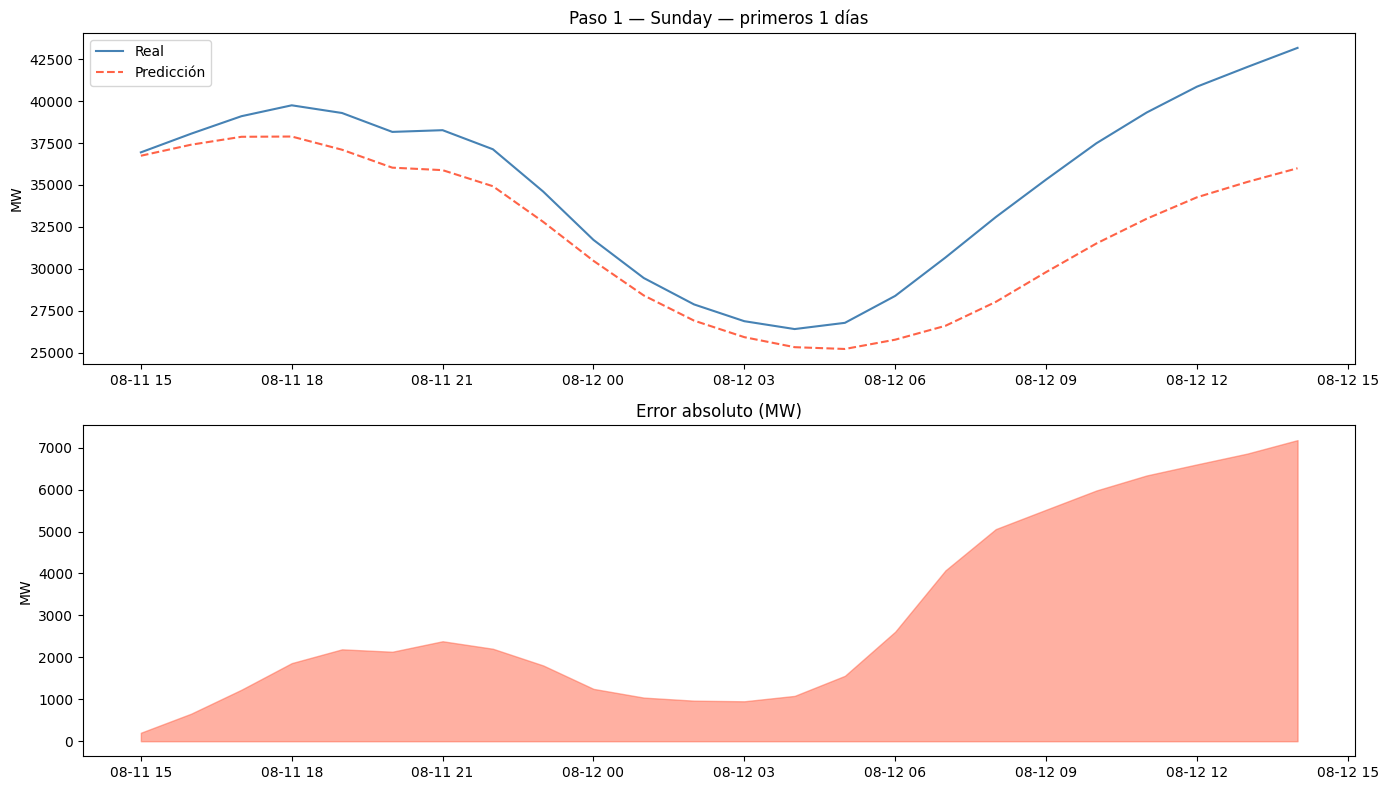


--- Paso 2 | 2013-08-12 15:00:00 → 2013-08-13 14:00:00 (Monday) ---

Métricas [Paso 2 — Monday]
  mean_true  : 37,343.0 MW
  std_true  : 5,953.9 MW
  MAE  : 1,958.9 MW
  RMSE : 2,409.7 MW
  MAPE : 5.67%
  R2 : 0.8362


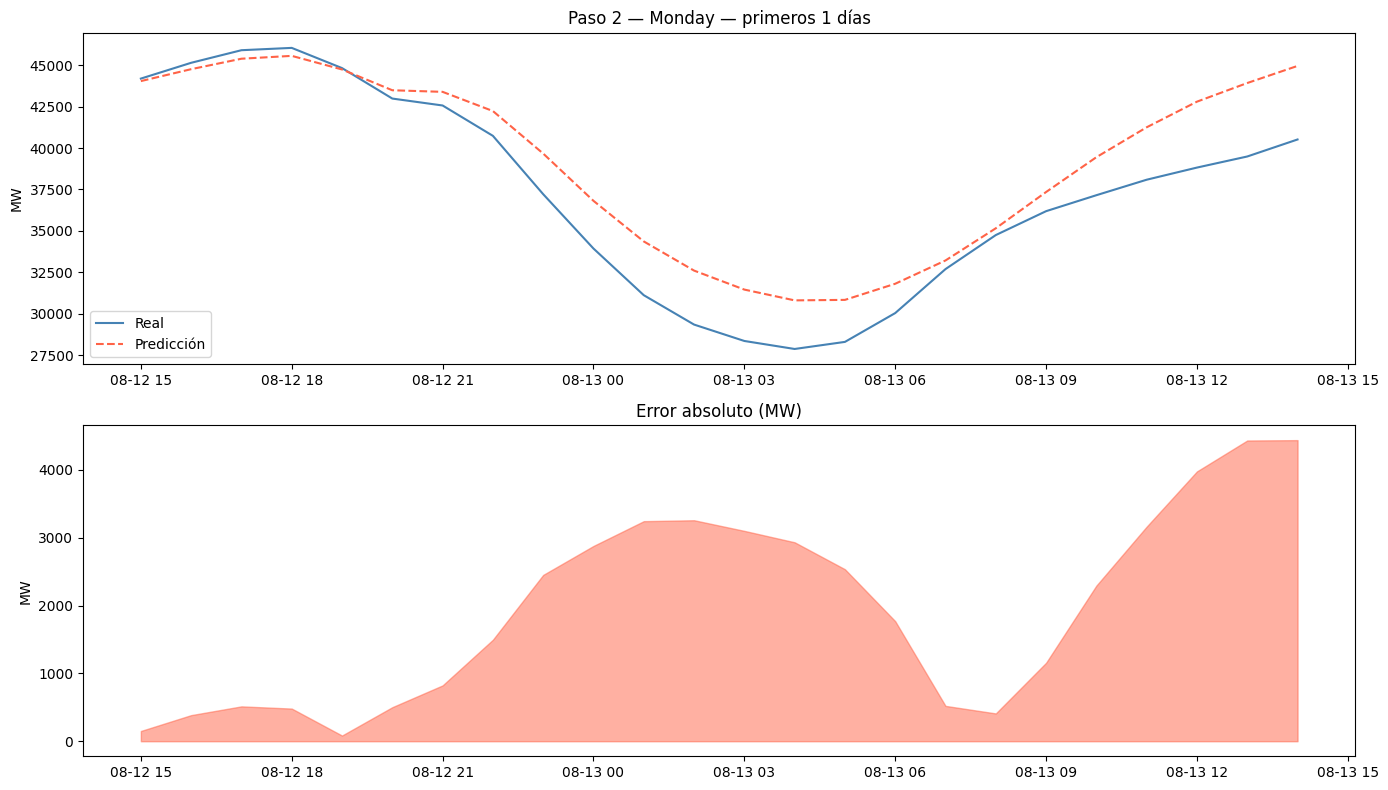


--- Paso 3 | 2013-08-13 15:00:00 → 2013-08-14 14:00:00 (Tuesday) ---

Métricas [Paso 3 — Tuesday]
  mean_true  : 34,047.8 MW
  std_true  : 6,339.8 MW
  MAE  : 2,772.7 MW
  RMSE : 3,458.3 MW
  MAPE : 9.06%
  R2 : 0.7024


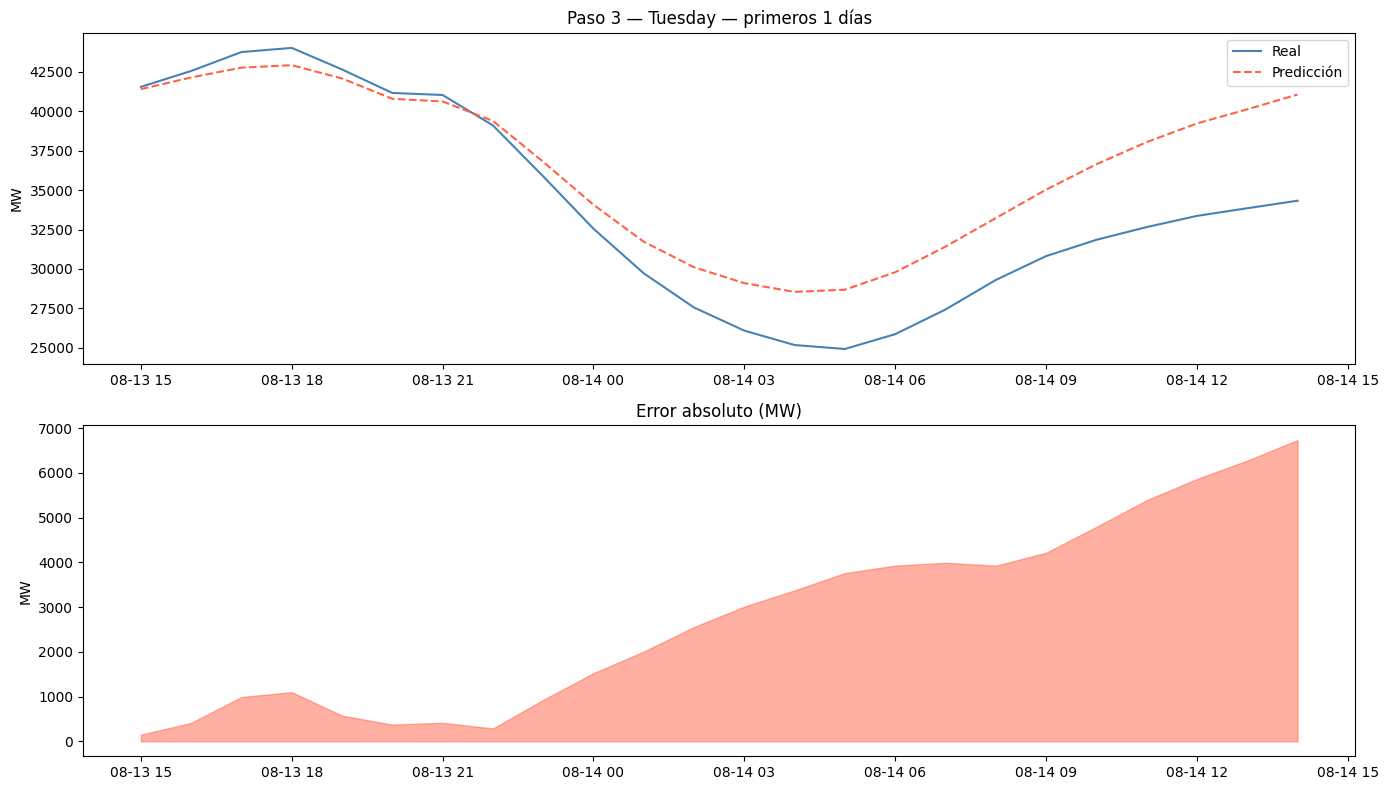


--- Paso 4 | 2013-08-14 15:00:00 → 2013-08-15 14:00:00 (Wednesday) ---

Métricas [Paso 4 — Wednesday]
  mean_true  : 29,801.6 MW
  std_true  : 4,524.2 MW
  MAE  : 944.2 MW
  RMSE : 1,039.7 MW
  MAPE : 3.25%
  R2 : 0.9472


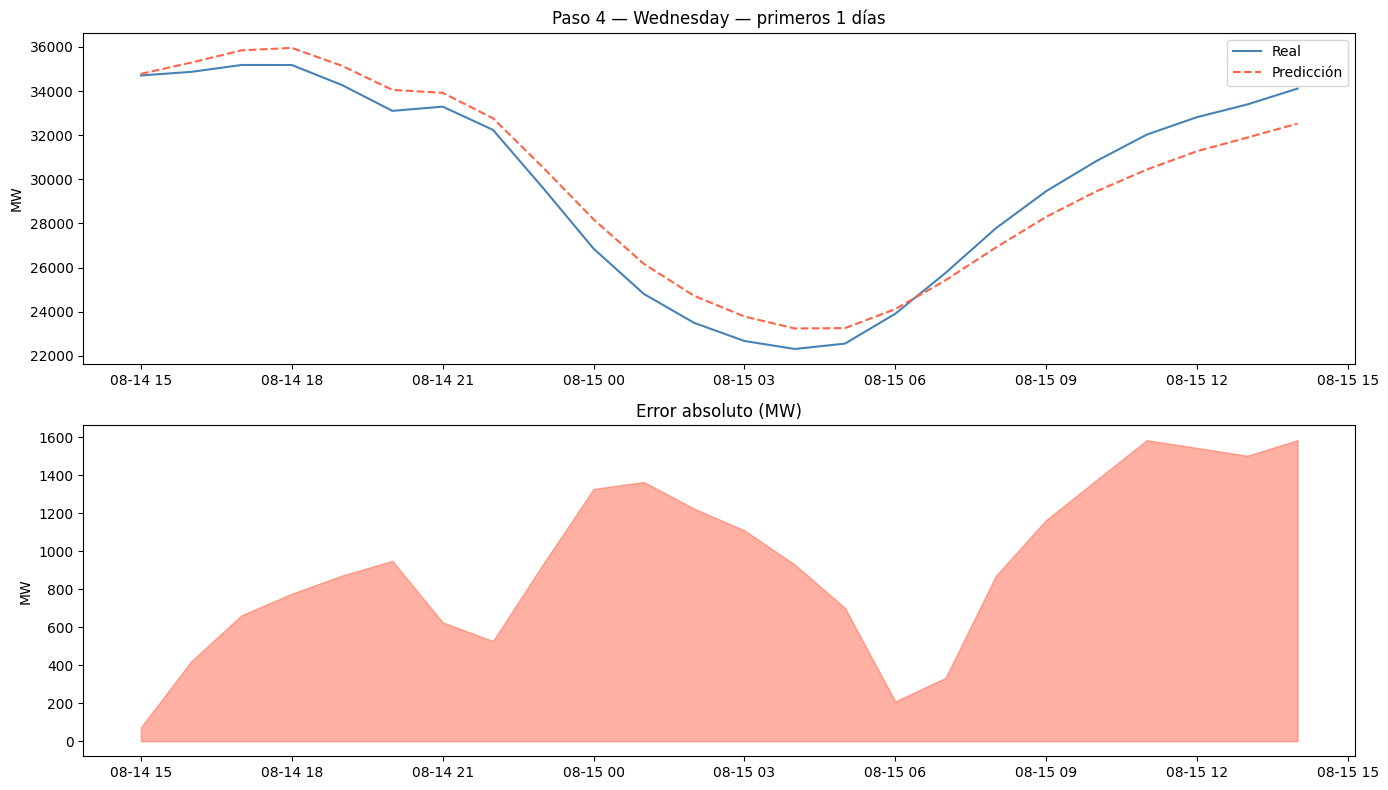


--- Paso 5 | 2013-08-15 15:00:00 → 2013-08-16 14:00:00 (Thursday) ---

Métricas [Paso 5 — Thursday]
  mean_true  : 30,269.0 MW
  std_true  : 4,750.5 MW
  MAE  : 716.1 MW
  RMSE : 957.0 MW
  MAPE : 2.48%
  R2 : 0.9594


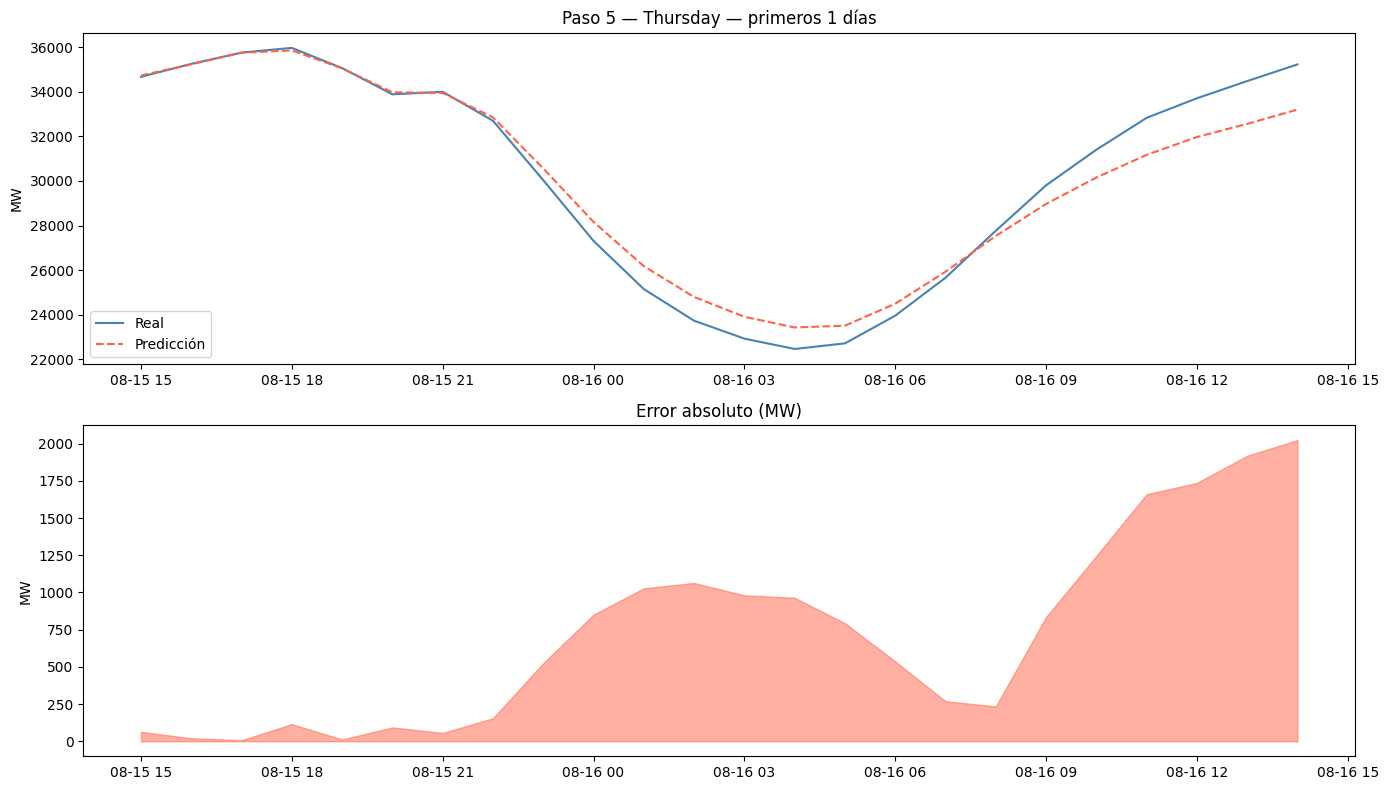


--- Paso 6 | 2013-08-16 15:00:00 → 2013-08-17 14:00:00 (Friday) ---

Métricas [Paso 6 — Friday]
  mean_true  : 29,123.0 MW
  std_true  : 5,017.6 MW
  MAE  : 2,035.5 MW
  RMSE : 2,386.8 MW
  MAPE : 7.66%
  R2 : 0.7737


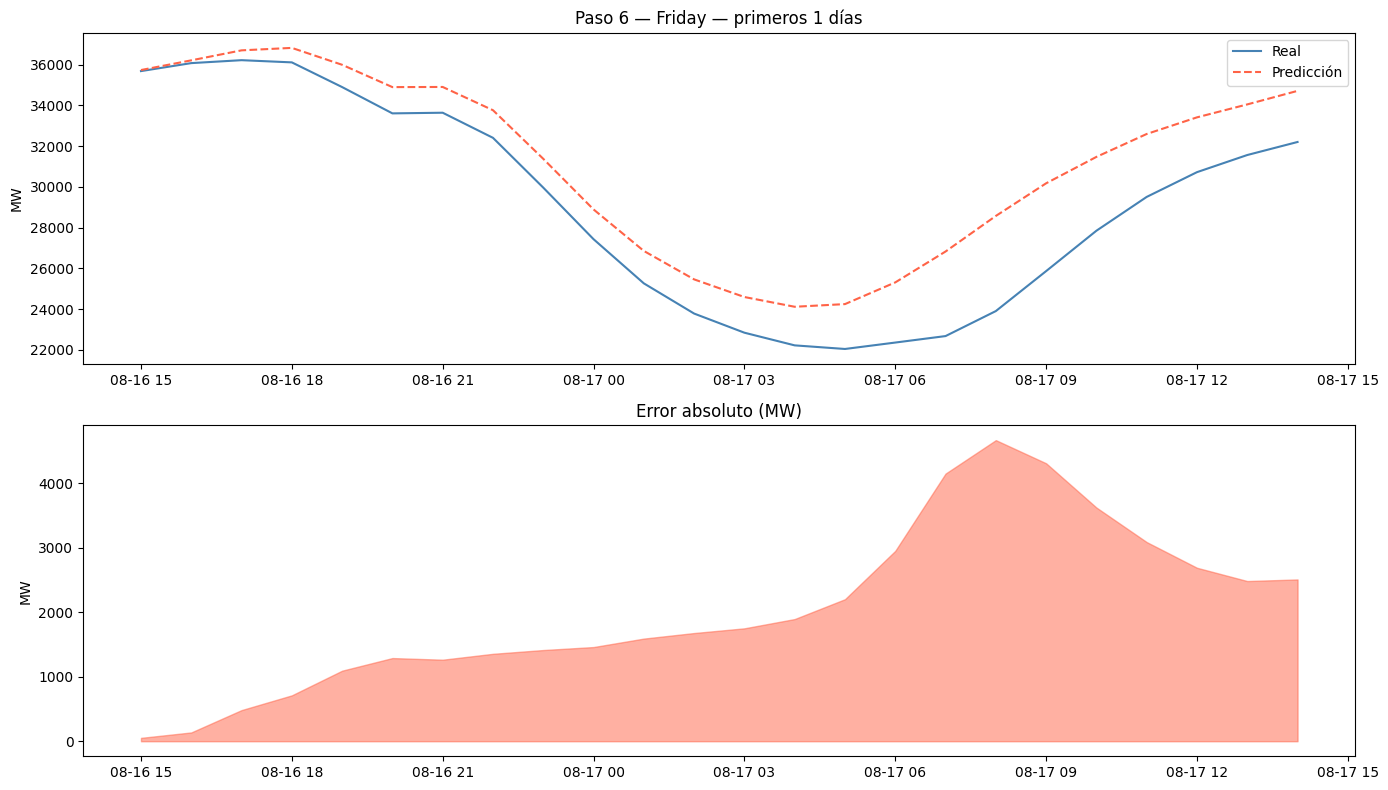


--- Paso 7 | 2013-08-17 15:00:00 → 2013-08-18 14:00:00 (Saturday) ---

Métricas [Paso 7 — Saturday]
  mean_true  : 28,186.8 MW
  std_true  : 4,044.3 MW
  MAE  : 832.6 MW
  RMSE : 926.5 MW
  MAPE : 3.06%
  R2 : 0.9475


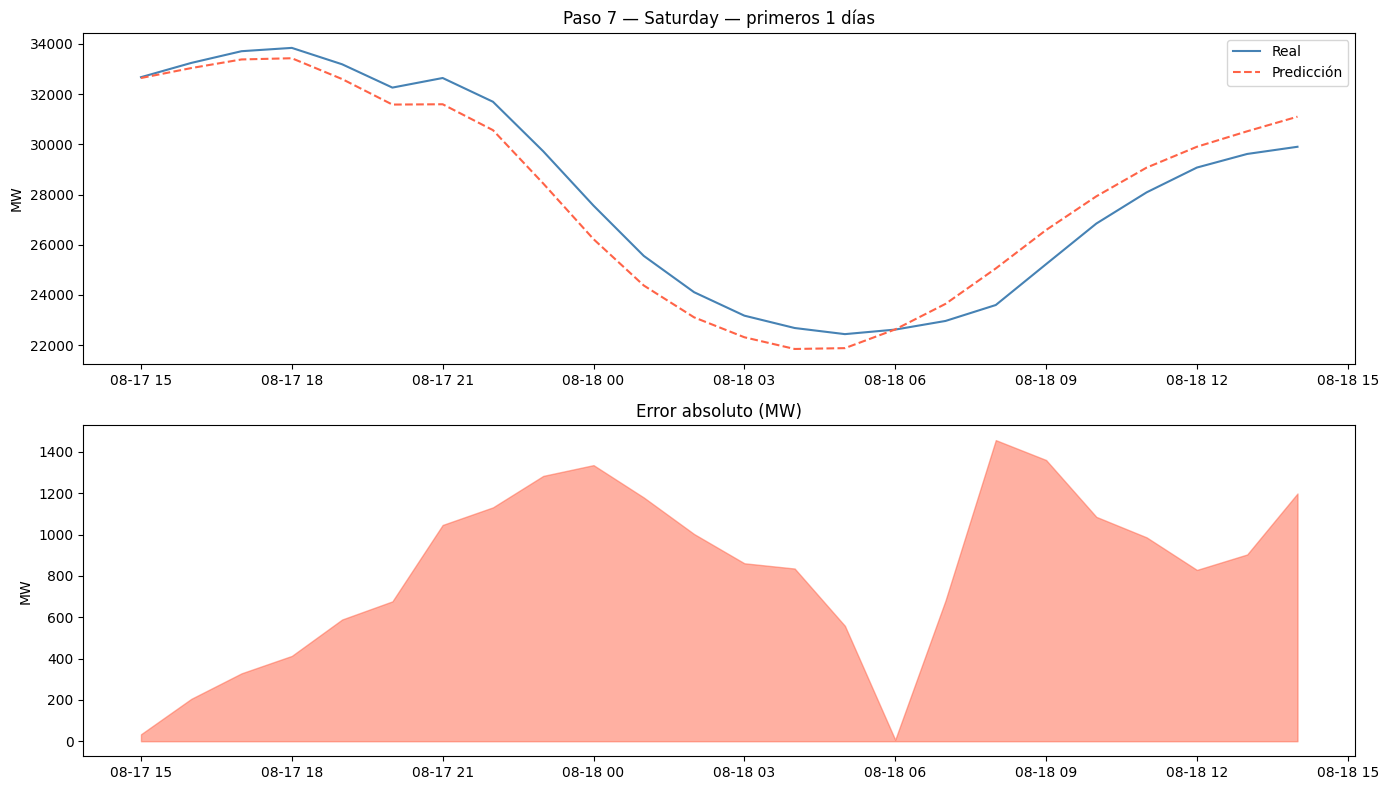


Métricas [Rolling Forecast 24h ahead — Global]
  mean_true  : 31,971.5 MW
  std_true  : 6,086.9 MW
  MAE  : 1,749.8 MW
  RMSE : 2,397.7 MW
  MAPE : 5.63%
  R2 : 0.8448


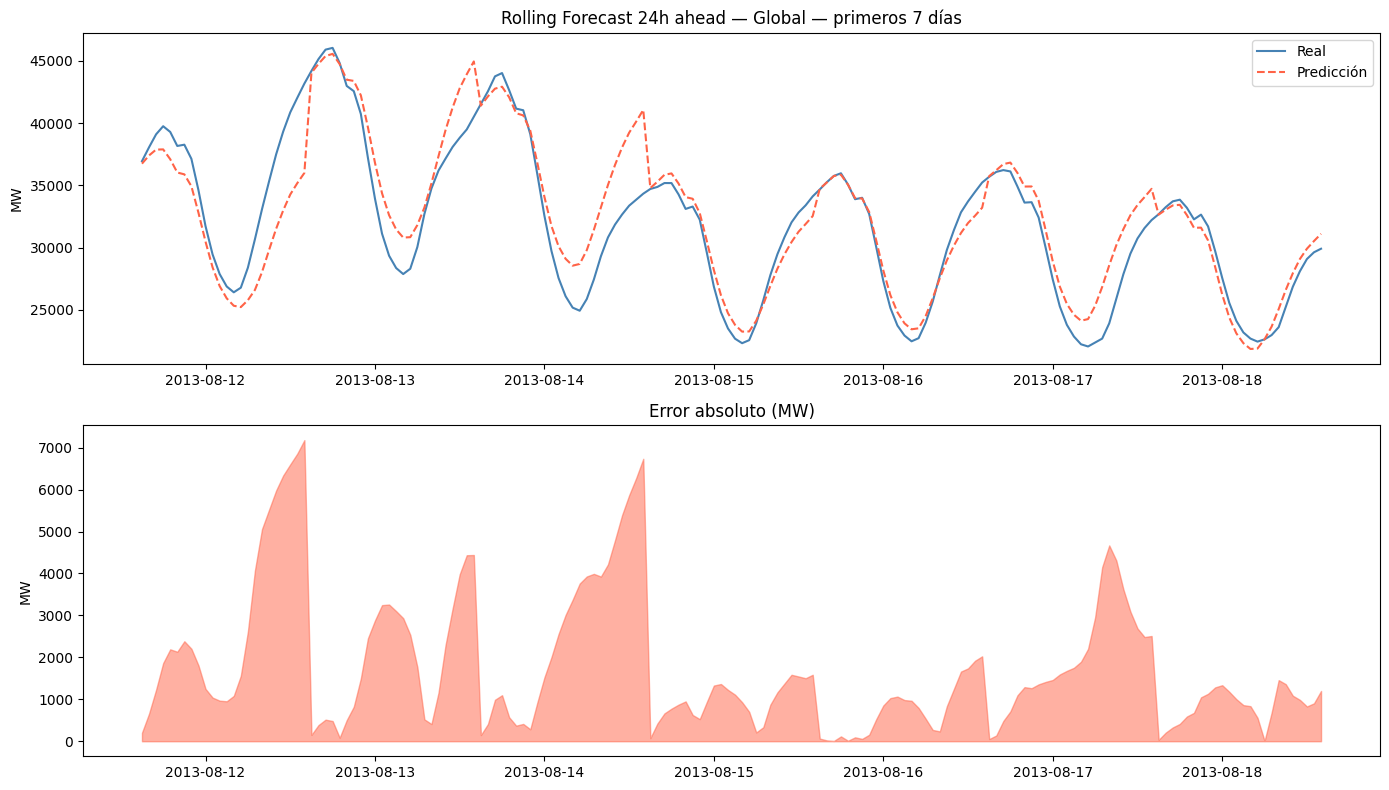

In [32]:
result_full = SARIMAXResultsWrapper.load(models_dir / 'sarimax_24.pkl')

# Warm-up: últimas 2 semanas del train
warm_up_inicial = endog_train.iloc[-168:]

# Datos a predecir: val completo desde donde parte
datos_alineados = endog_val.asfreq('h')

print(f"Warm-up: {warm_up_inicial.index[0]} → {warm_up_inicial.index[-1]}")
print(f"Datos:   {datos_alineados.index[0]} → {datos_alineados.index[-1]}")
print(f"Gap:     {datos_alineados.index[0] - warm_up_inicial.index[-1]}")

result_updated = result_full.apply(warm_up_inicial)
preds = []
n_dias = 7

# Bloques de 24h desde el primer valor de endog_val
inicio = datos_alineados.index[0]
bloques = [(inicio + pd.Timedelta(hours=24*d),
            inicio + pd.Timedelta(hours=24*d + 23))
           for d in range(n_dias)]

for idx, (t_ini, t_fin) in enumerate(bloques):
    if t_ini not in datos_alineados.index:
        break
    t_fin = min(t_fin, datos_alineados.index[-1])

    steps = len(datos_alineados[t_ini:t_fin])
    fc = result_updated.get_forecast(steps=steps)

    real_step_mw  = np.exp(datos_alineados[t_ini:t_fin])
    pred_step_log = fc.predicted_mean
    pred_step_log.index = real_step_mw.index
    pred_step_mw  = np.exp(pred_step_log)

    dia_nombre = t_ini.day_name()
    print(f"\n--- Paso {idx+1} | {t_ini} → {t_fin} ({dia_nombre}) ---")
    evaluate(real_step_mw, pred_step_mw, f'Paso {idx+1} — {dia_nombre}')
    plot_forecast(real_step_mw, pred_step_mw, f'Paso {idx+1} — {dia_nombre}', n_days=1)

    preds.append(pred_step_log)

    # Re-apply acumulativo
    historia_acumulada = pd.concat([warm_up_inicial, datos_alineados[:t_fin]])
    result_updated = result_full.apply(historia_acumulada)

# Resumen global
pred_log = pd.concat(preds)
pred_mw  = np.exp(pred_log)
real_mw  = np.exp(datos_alineados[:len(pred_mw)])
evaluate(real_mw, pred_mw, 'Rolling Forecast 24h ahead — Global')
plot_forecast(real_mw, pred_mw, 'Rolling Forecast 24h ahead — Global', n_days=n_dias)

Warm-up termina en: 2013-08-10 23:00:00
Datos desde:        2013-08-11 00:00:00
Gap:                0 days 01:00:00

--- Paso 1 | 2013-08-11 (Sunday) ---
  Modelo actualizado hasta: 2013-08-10 23:00:00
  Prediciendo desde:        2013-08-11 00:00:00
  Prediciendo hasta:        2013-08-11 23:00:00
  Real desde:               2013-08-11 00:00:00
  Real hasta:               2013-08-11 23:00:00

Métricas [Paso 1 — Sunday]
  mean_true  : 31,840.0 MW
  std_true  : 5,700.4 MW
  MAE  : 2,058.3 MW
  RMSE : 2,453.0 MW
  MAPE : 7.03%
  R2 : 0.8148


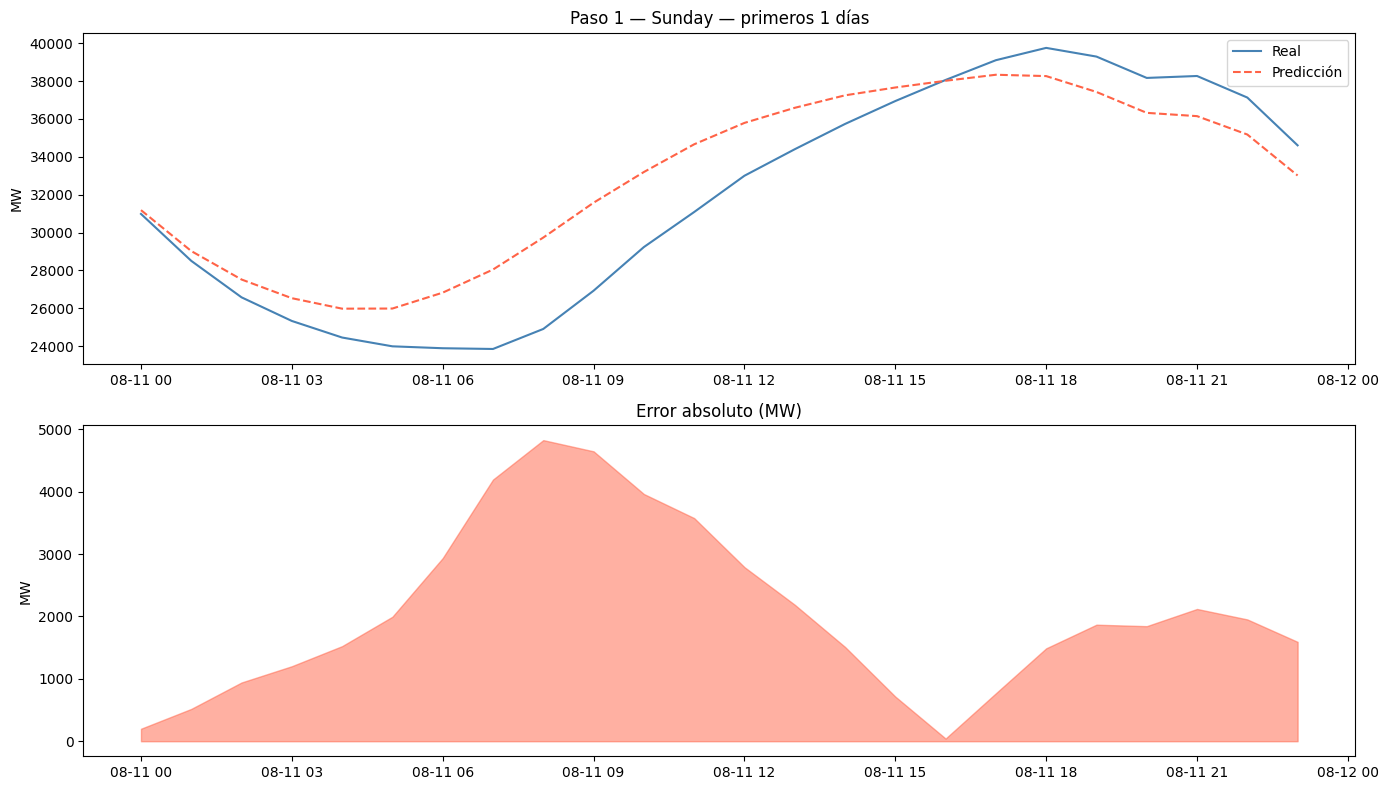

  → extend() agregó: 2013-07-28 00:00:00 → 2013-08-11 23:00:00
  Endog shape tras extend: (360, 1)

--- Paso 2 | 2013-08-12 (Monday) ---
  Modelo actualizado hasta: 2013-08-11 23:00:00
  Prediciendo desde:        2013-08-12 00:00:00
  Prediciendo hasta:        2013-08-12 23:00:00
  Real desde:               2013-08-12 00:00:00
  Real hasta:               2013-08-12 23:00:00

Métricas [Paso 2 — Monday]
  mean_true  : 37,042.5 MW
  std_true  : 6,847.5 MW
  MAE  : 3,702.5 MW
  RMSE : 4,356.8 MW
  MAPE : 9.15%
  R2 : 0.5952


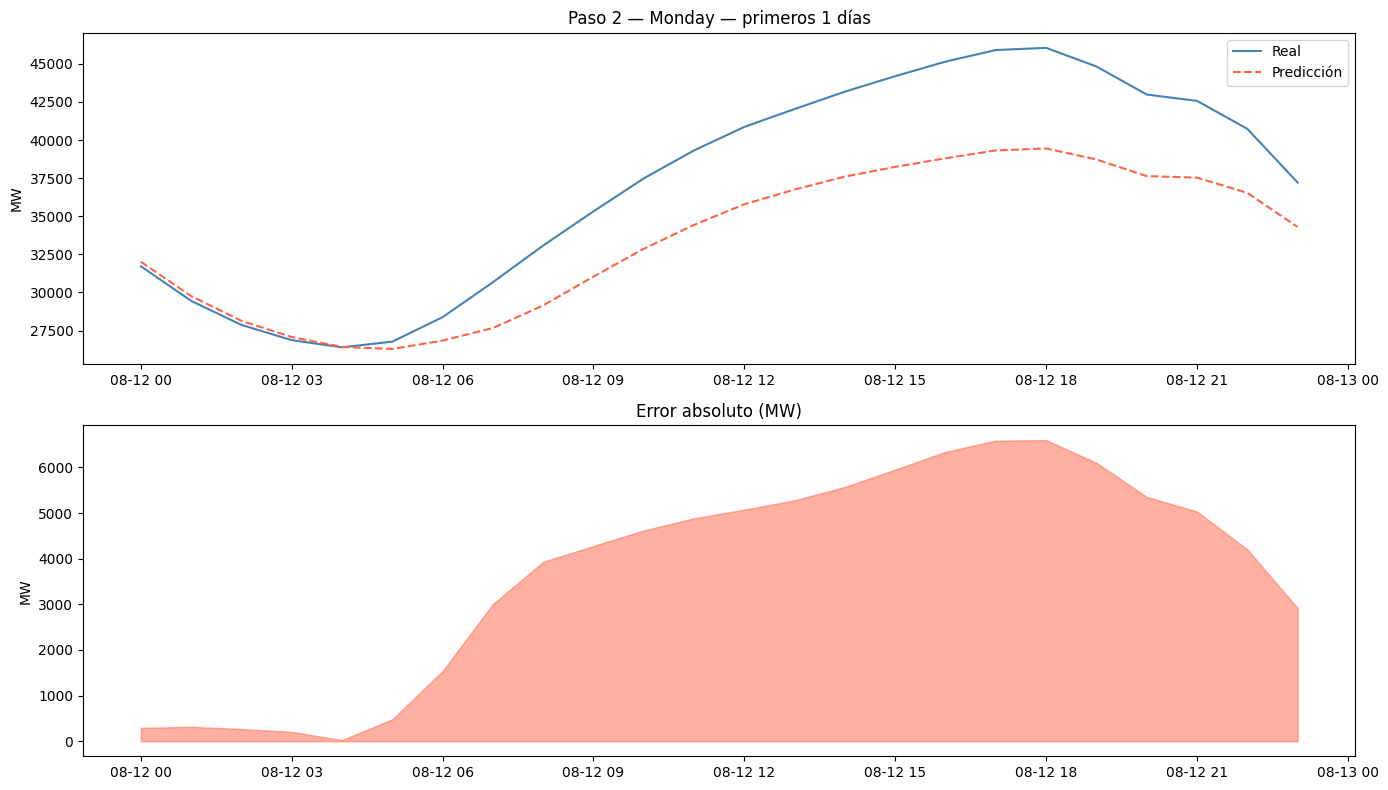

  → extend() agregó: 2013-07-28 00:00:00 → 2013-08-12 23:00:00
  Endog shape tras extend: (384, 1)

--- Paso 3 | 2013-08-13 (Tuesday) ---
  Modelo actualizado hasta: 2013-08-12 23:00:00
  Prediciendo desde:        2013-08-13 00:00:00
  Prediciendo hasta:        2013-08-13 23:00:00
  Real desde:               2013-08-13 00:00:00
  Real hasta:               2013-08-13 23:00:00

Métricas [Paso 3 — Tuesday]
  mean_true  : 36,597.2 MW
  std_true  : 5,189.4 MW
  MAE  : 883.6 MW
  RMSE : 1,267.6 MW
  MAPE : 2.43%
  R2 : 0.9403


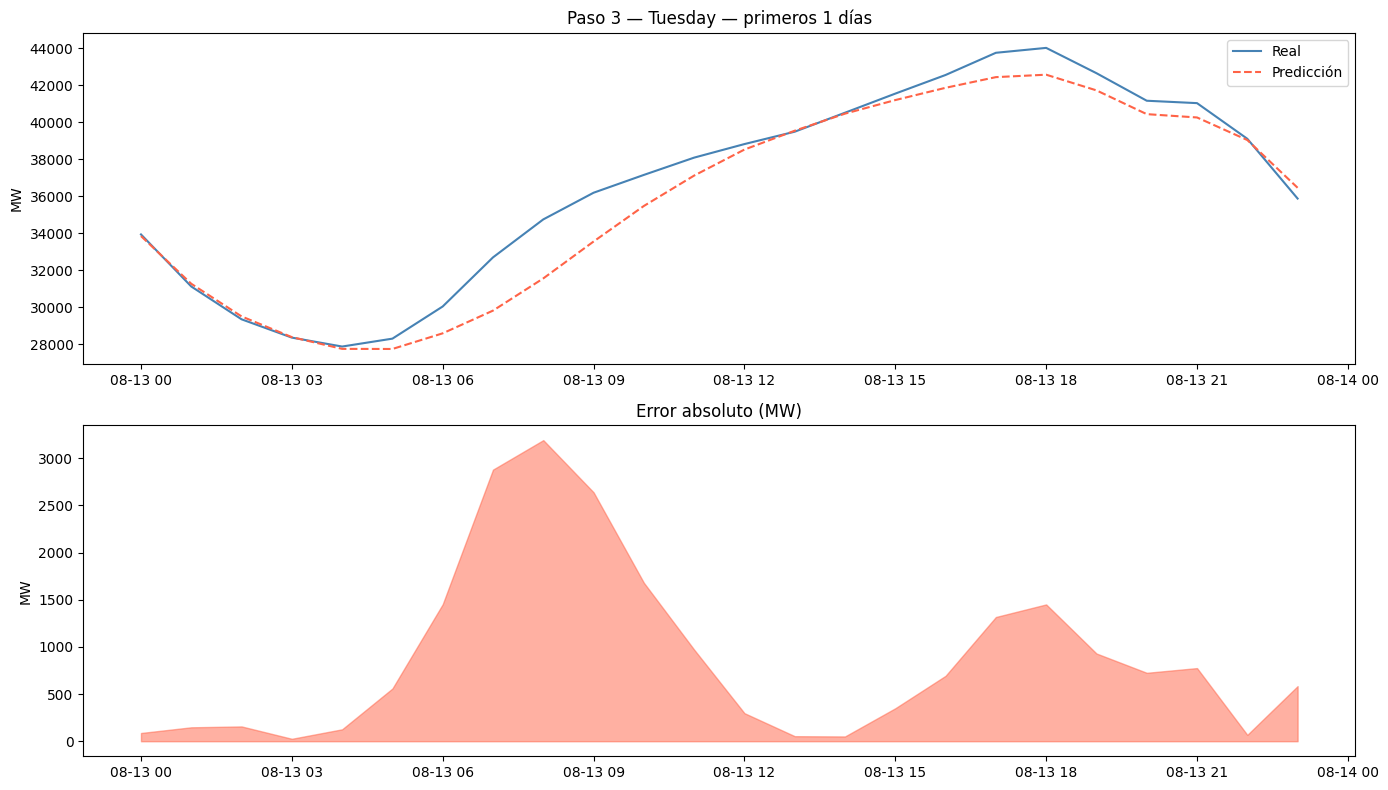

  → extend() agregó: 2013-07-28 00:00:00 → 2013-08-13 23:00:00
  Endog shape tras extend: (408, 1)

--- Paso 4 | 2013-08-14 (Wednesday) ---
  Modelo actualizado hasta: 2013-08-13 23:00:00
  Prediciendo desde:        2013-08-14 00:00:00
  Prediciendo hasta:        2013-08-14 23:00:00
  Real desde:               2013-08-14 00:00:00
  Real hasta:               2013-08-14 23:00:00

Métricas [Paso 4 — Wednesday]
  mean_true  : 31,161.8 MW
  std_true  : 3,343.4 MW
  MAE  : 3,897.1 MW
  RMSE : 4,347.1 MW
  MAPE : 12.18%
  R2 : -0.6906


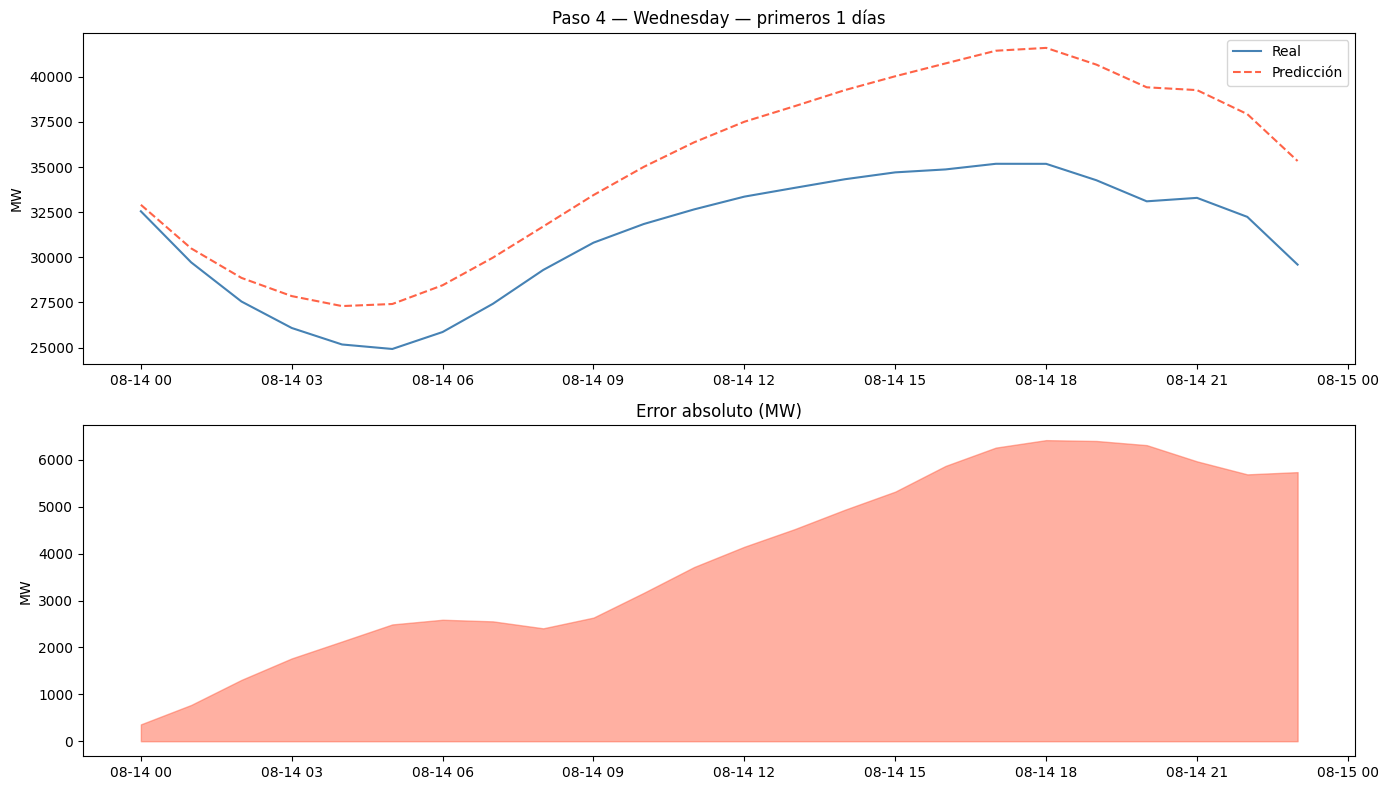

  → extend() agregó: 2013-07-28 00:00:00 → 2013-08-14 23:00:00
  Endog shape tras extend: (432, 1)

--- Paso 5 | 2013-08-15 (Thursday) ---
  Modelo actualizado hasta: 2013-08-14 23:00:00
  Prediciendo desde:        2013-08-15 00:00:00
  Prediciendo hasta:        2013-08-15 23:00:00
  Real desde:               2013-08-15 00:00:00
  Real hasta:               2013-08-15 23:00:00

Métricas [Paso 5 — Thursday]
  mean_true  : 30,004.8 MW
  std_true  : 4,702.8 MW
  MAE  : 2,387.7 MW
  RMSE : 2,755.1 MW
  MAPE : 7.42%
  R2 : 0.6568


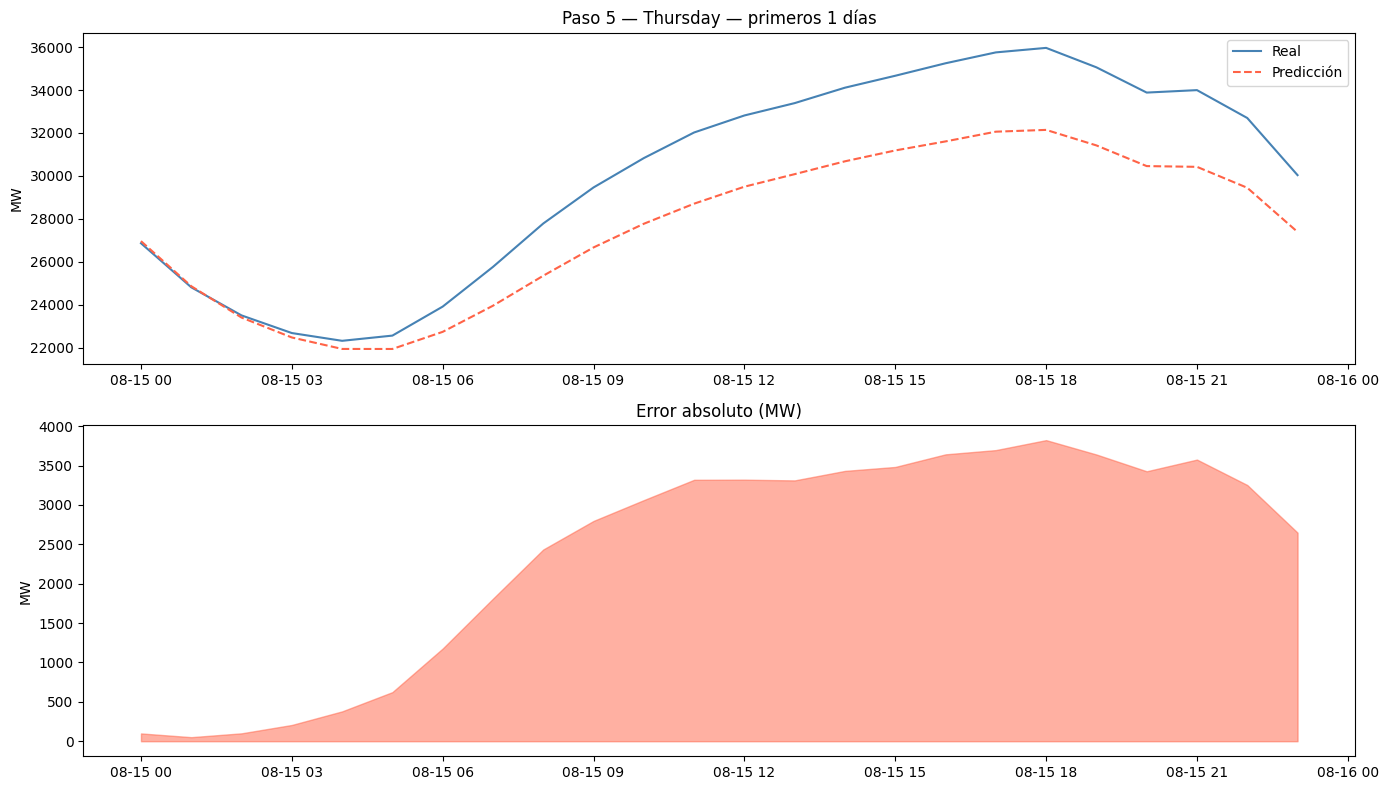

  → extend() agregó: 2013-07-28 00:00:00 → 2013-08-15 23:00:00
  Endog shape tras extend: (456, 1)

--- Paso 6 | 2013-08-16 (Friday) ---
  Modelo actualizado hasta: 2013-08-15 23:00:00
  Prediciendo desde:        2013-08-16 00:00:00
  Prediciendo hasta:        2013-08-16 23:00:00
  Real desde:               2013-08-16 00:00:00
  Real hasta:               2013-08-16 23:00:00

Métricas [Paso 6 — Friday]
  mean_true  : 30,324.1 MW
  std_true  : 4,832.0 MW
  MAE  : 1,614.4 MW
  RMSE : 1,955.7 MW
  MAPE : 4.88%
  R2 : 0.8362


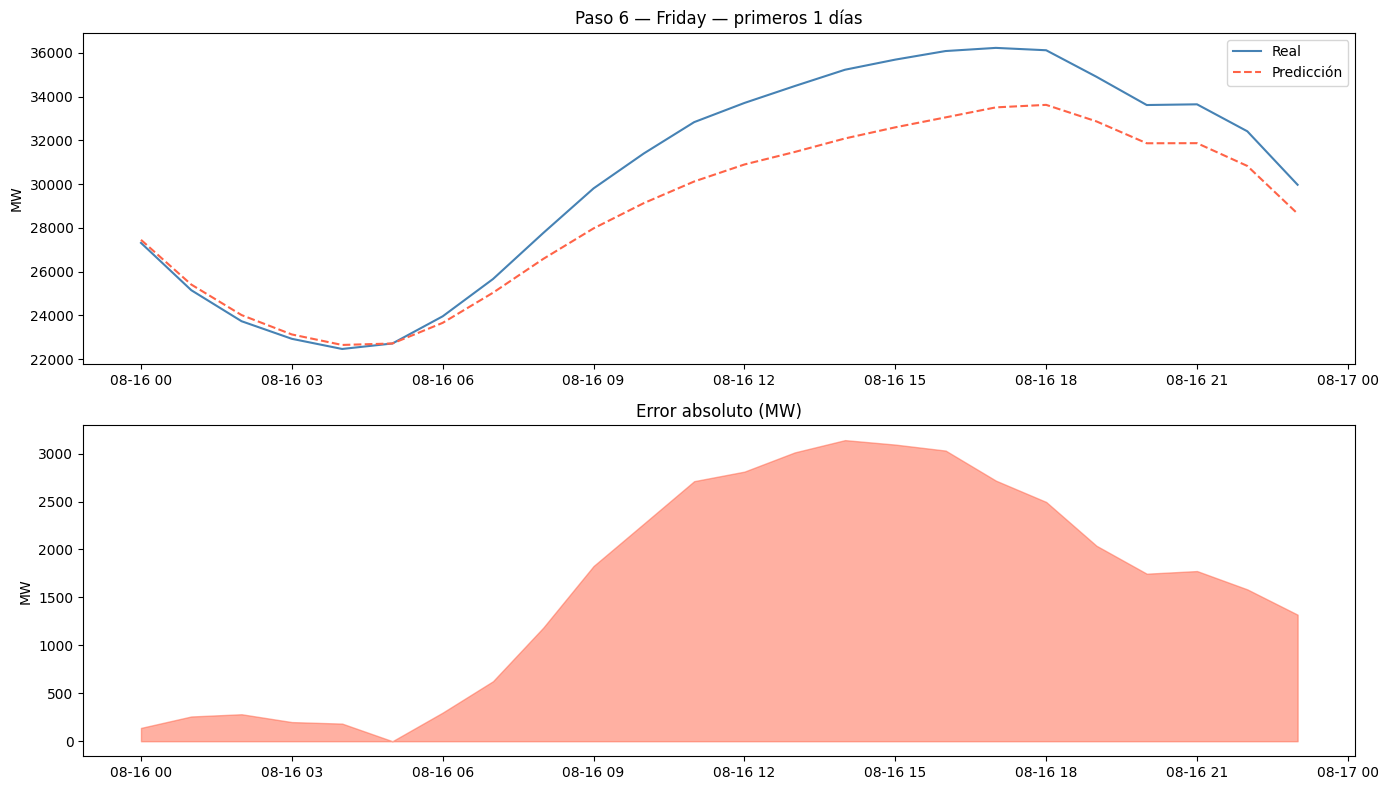

  → extend() agregó: 2013-07-28 00:00:00 → 2013-08-16 23:00:00
  Endog shape tras extend: (480, 1)

--- Paso 7 | 2013-08-17 (Saturday) ---
  Modelo actualizado hasta: 2013-08-16 23:00:00
  Prediciendo desde:        2013-08-17 00:00:00
  Prediciendo hasta:        2013-08-17 23:00:00
  Real desde:               2013-08-17 00:00:00
  Real hasta:               2013-08-17 23:00:00

Métricas [Paso 7 — Saturday]
  mean_true  : 28,471.4 MW
  std_true  : 4,265.0 MW
  MAE  : 968.0 MW
  RMSE : 1,303.8 MW
  MAPE : 3.70%
  R2 : 0.9066


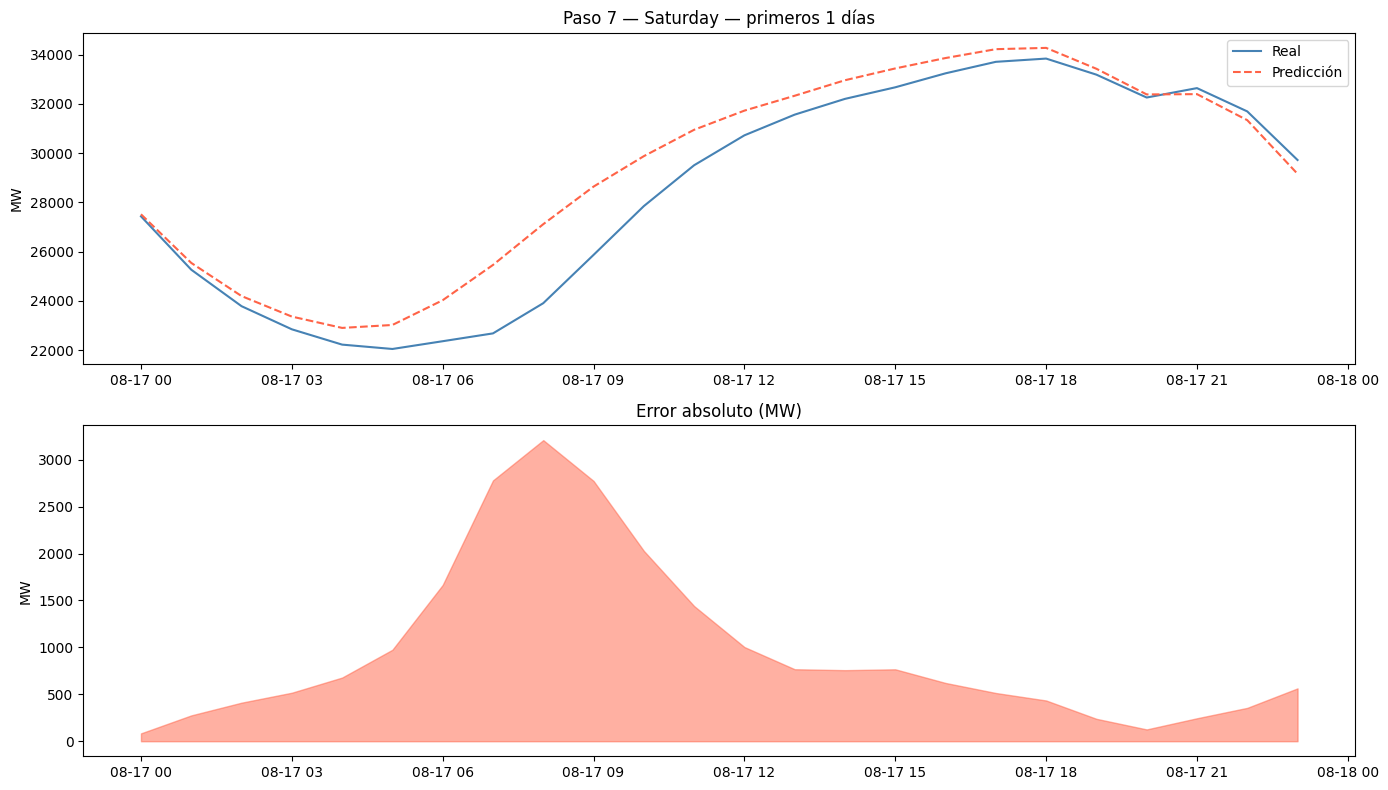

  → extend() agregó: 2013-07-28 00:00:00 → 2013-08-17 23:00:00
  Endog shape tras extend: (504, 1)


Métricas [Rolling Forecast 24h ahead — Global]
  mean_true  : 32,206.0 MW
  std_true  : 5,944.7 MW
  MAE  : 2,216.0 MW
  RMSE : 2,893.8 MW
  MAPE : 6.68%
  R2 : 0.7630


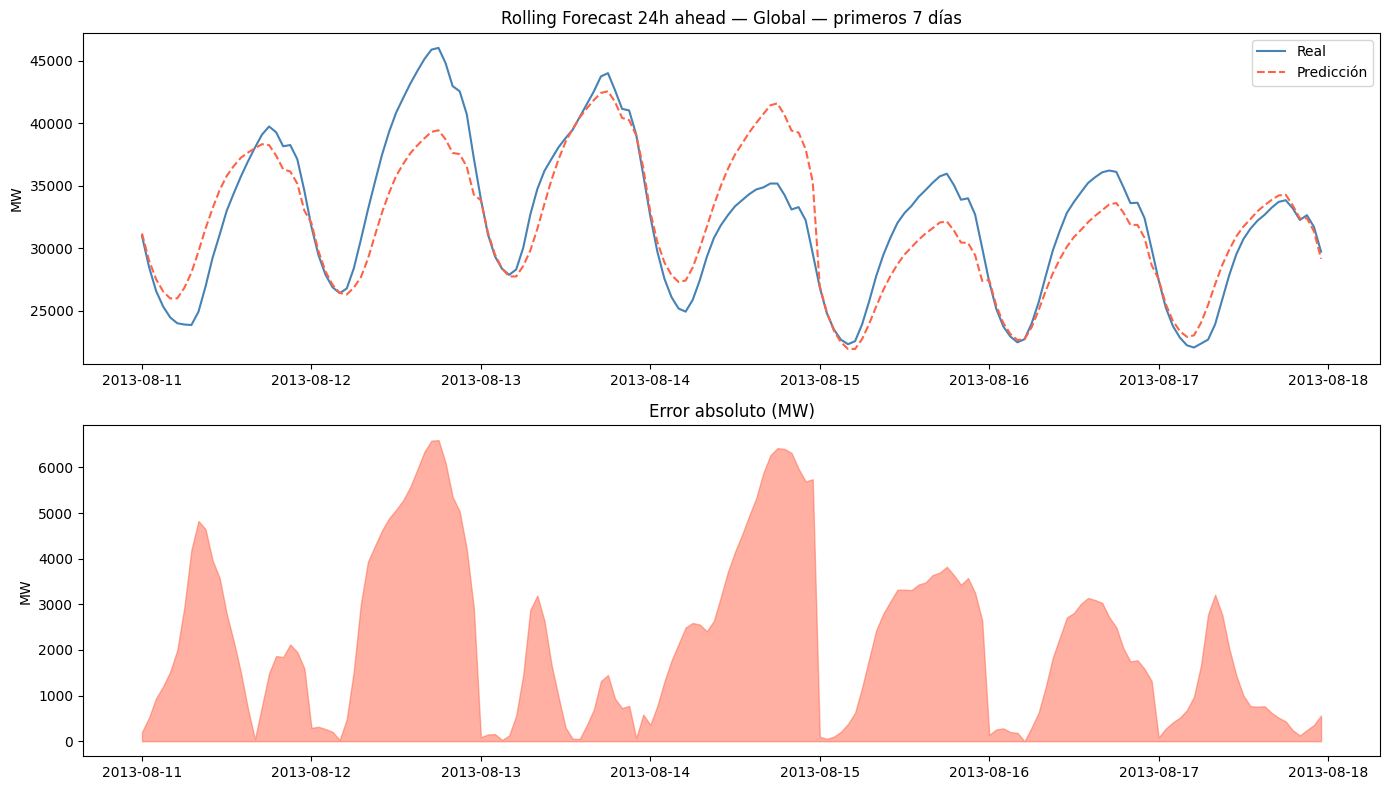

In [19]:
result_full = SARIMAXResultsWrapper.load(models_dir / 'sarimax_24.pkl')

# Construir serie continua: fin del train + inicio de val
serie_continua = pd.concat([endog_train, endog_val]).asfreq('h')

# Warm-up alineado
ultimo_23_train = endog_train[endog_train.index.hour == 23].index[-1]
#warm_up_inicial = serie_continua[:ultimo_23_train].iloc[-48:]
warm_up_inicial = serie_continua[:ultimo_23_train].iloc[-336:]

# Primer 00:00 disponible DESPUÉS del warm-up en la serie continua
inicio_busqueda    = ultimo_23_train + pd.Timedelta('1h')
primer_00          = serie_continua[inicio_busqueda:][serie_continua[inicio_busqueda:].index.hour == 0].index[0]
datos_alineados    = serie_continua[primer_00:].asfreq('h')

print(f"Warm-up termina en: {warm_up_inicial.index[-1]}")
print(f"Datos desde:        {datos_alineados.index[0]}")
print(f"Gap:                {datos_alineados.index[0] - warm_up_inicial.index[-1]}")
# → debe dar 0 days 01:00:00

result_updated = result_full.apply(warm_up_inicial)

preds = []
n_dias = 7

for i in range(0, n_dias * 24, 24):
    if i + 24 > len(datos_alineados):
        break

    fc = result_updated.get_forecast(steps=24)

    # Usar datos_alineados para el real — misma serie, mismo índice
    real_step_mw  = np.exp(datos_alineados.iloc[i:i+24])
    pred_step_log = fc.predicted_mean
    pred_step_log.index = real_step_mw.index
    pred_step_mw  = np.exp(pred_step_log)

    dia = real_step_mw.index[0].day_name()

    print(f"\n--- Paso {i//24+1} | {real_step_mw.index[0].date()} ({dia}) ---")
    print(f"  Modelo actualizado hasta: {result_updated.fittedvalues.index[-1]}")
    print(f"  Prediciendo desde:        {fc.predicted_mean.index[0]}")
    print(f"  Prediciendo hasta:        {fc.predicted_mean.index[-1]}")
    print(f"  Real desde:               {real_step_mw.index[0]}")
    print(f"  Real hasta:               {real_step_mw.index[-1]}")

    evaluate(real_step_mw, pred_step_mw, f'Paso {i//24+1} — {dia}')
    plot_forecast(real_step_mw, pred_step_mw, f'Paso {i//24+1} — {dia}', n_days=1)

    preds.append(pred_step_log)

    # nuevos_datos   = datos_alineados.iloc[i:i+24]
    # nuevos_datos = pd.concat([warm_up_inicial, datos_alineados.iloc[:i+24]])
    # result_updated = result_updated.extend(nuevos_datos)
    nuevos_datos = pd.concat([warm_up_inicial, datos_alineados.iloc[:i+24]])
    result_updated = result_full.apply(nuevos_datos)
    print(f"  → extend() agregó: {nuevos_datos.index[0]} → {nuevos_datos.index[-1]}")
    print(f"  Endog shape tras extend: {result_updated.model.endog.shape}")
# Resumen global
print("\n" + "="*50)
pred_log = pd.concat(preds)
pred_mw  = np.exp(pred_log)
real_mw  = np.exp(datos_alineados.iloc[:len(pred_mw)])
evaluate(real_mw, pred_mw, 'Rolling Forecast 24h ahead — Global')
plot_forecast(real_mw, pred_mw, 'Rolling Forecast 24h ahead — Global', n_days=n_dias)

In [15]:
print(type(result_updated.model.endog))
print(result_updated.model.endog.shape)
print(result_updated.model.endog[-5:])

<class 'numpy.ndarray'>
(24, 1)
[[10.41006416]
 [10.38167634]
 [10.39344698]
 [10.36404041]
 [10.29974372]]



Métricas [Test (sin warmup)]
  mean_true  : 31,101.2 MW
  std_true  : 6,441.8 MW
  MAE  : 212.1 MW
  RMSE : 292.2 MW
  MAPE : 0.70%
  R2 : 0.9979


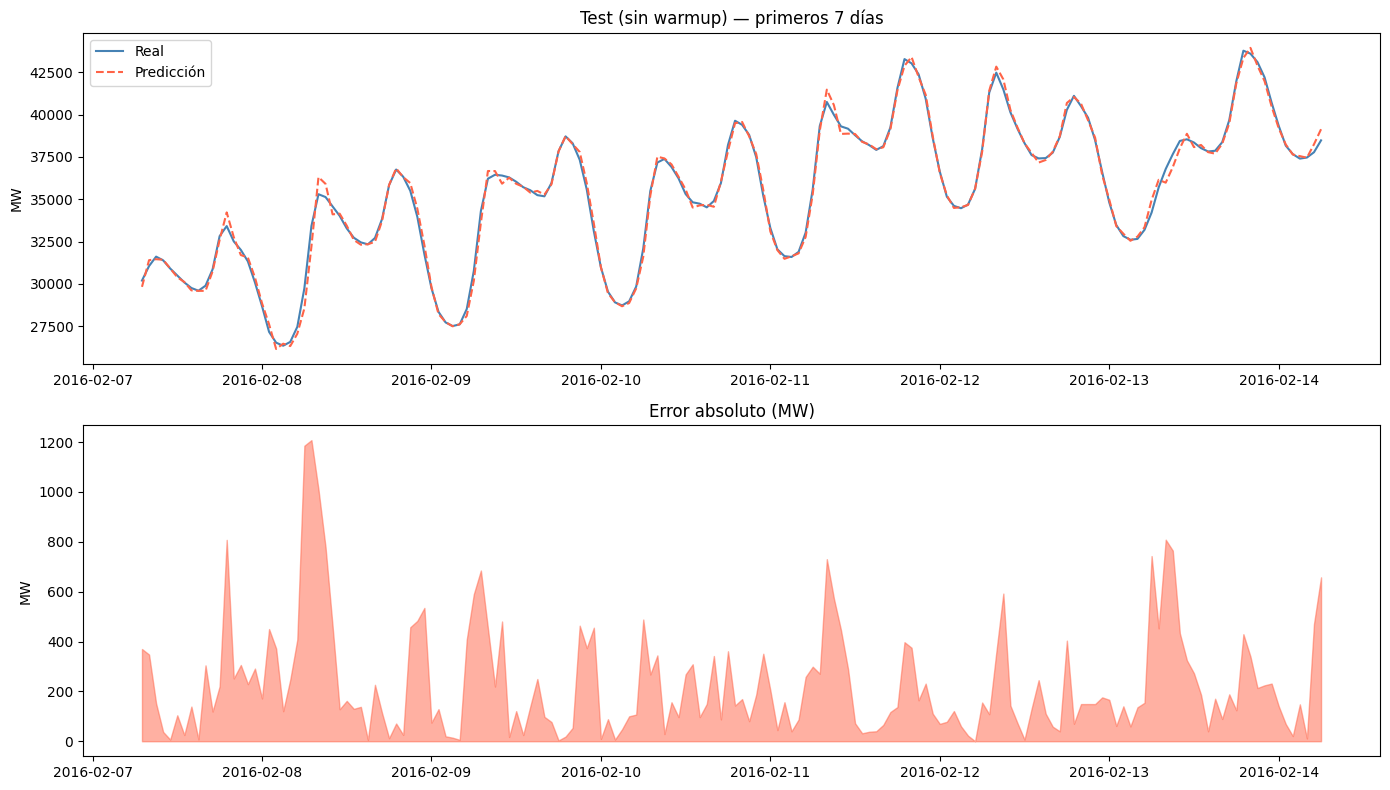

In [ ]:
# Evaluación in-sample sobre test
result_test = result.apply(endog_test)
pred_test_log = result_test.fittedvalues

pred_test = np.exp(pred_test_log)
real_test = np.exp(endog_test)

assert (real_test.index == pred_test.index).all()

warmup = 24
metrics_test = evaluate(real_test.iloc[warmup:], pred_test.iloc[warmup:], 'Test (sin warmup)')
plot_forecast(real_test.iloc[warmup:], pred_test.iloc[warmup:], 'Test (sin warmup)')


Métricas [Validation Forecast]
  mean_true  : 35,029.5 MW
  std_true  : 5,156.2 MW
  MAE  : 3,101.0 MW
  RMSE : 3,855.7 MW
  MAPE : 8.58%
  R2 : 0.4408


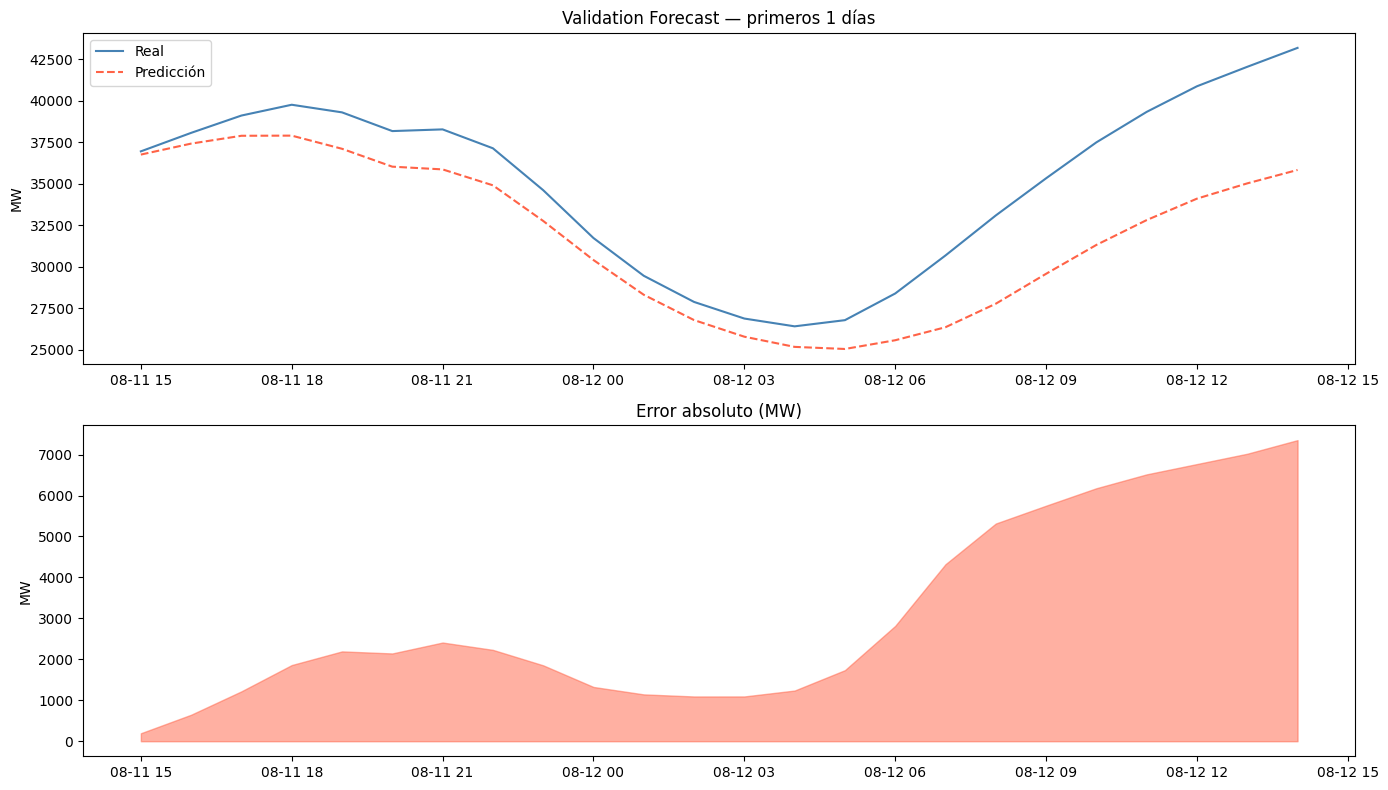

In [18]:
# history = pd.concat([endog_train, endog_val])

result_updated = result.apply(endog_train)
# result_updated = result.extend(history)

forecast = result_updated.get_forecast(steps=24)

pred_log = forecast.predicted_mean
# pred_log.index = endog_val.index

pred_mw = np.exp(pred_log)
real_mw = np.exp(endog_val.iloc[:24])

evaluate(real_mw, pred_mw, 'Validation Forecast')
plot_forecast(real_mw, pred_mw, 'Validation Forecast', n_days=1)

In [ ]:
# # Flujo típico en producción
# # 1. Cargar modelo guardado
# result_full = SARIMAXResultsWrapper.load(models_dir / 'sarimax_24.pkl')

# # 2. Si llegaron datos nuevos desde que entrenaste, extender el modelo
# result_updated = result_full.apply(nuevos_datos_log)

# # 3. Predecir las próximas 24 horas desde el último dato conocido
# forecast = result_updated.get_forecast(steps=24)
# pred_mw  = np.exp(forecast.predicted_mean)

# print(f"Predicción próximas 24h:")
# print(pred_mw)